# Assess the hindcast surface MLD variability

In [121]:
import sys
import os
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import scipy as sci
import glob

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
from cmocean.tools import lighten

import xesmf as xe

# Ensure we are in the correct directory
os.chdir("/home/581/pjb581/analysis_samw")
print(os.getcwd())

print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("xarray version =", xr.__version__)
print("scipy version =", sci.__version__)
print("xesmf version =", xe.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)

print(datetime.now())

"""
NOTE: Need read permissions for group es60
"""

/home/581/pjb581/analysis_samw
python version = 3.10.
numpy version = 2.1.3
xarray version = 2024.11.0
scipy version = 1.15.1
xesmf version = 0.8.8
matplotlib version = 3.10.0
cmocean version = v3.0.3
cartopy version = 0.24.0
2025-03-06 14:55:48.135933


'\nNOTE: Need read permissions for group es60\n'

## Load MLD data

In [122]:
%%time

datapath = "/g/data/es60/pjb581/JRA55-NEMO-PISCES/JRA55_pic_1m_mld_1958-2022.nc"

mod = xr.open_dataset(datapath)

# correct the coordinates and fix names
month = np.arange(1,13,1)
year = np.arange(1958.5,2022.51,1)
mod = mod.assign_coords(record=year)
mod = mod.assign_coords(time_counter=month)
mod = mod.rename({'nav_lon':'lon', 'nav_lat':'lat', 'record':'year', 'time_counter':'month'})

# retrieve information
lon = mod.coords['lon']
lat = mod.coords['lat']

mod

CPU times: user 18.2 ms, sys: 4.12 ms, total: 22.4 ms
Wall time: 20.5 ms


<xarray.Dataset> Size: 93MB
Dimensions:               (year: 65, y: 149, x: 182, nvertex: 4, month: 12,
                           axis_nbounds: 2)
Coordinates:
    lat                   (y, x) float32 108kB ...
    lon                   (y, x) float32 108kB ...
    time_centered         (month) object 96B ...
  * year                  (year) float64 520B 1.958e+03 1.96e+03 ... 2.022e+03
  * month                 (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    area                  (year, y, x) float32 7MB ...
    bounds_nav_lat        (y, x, nvertex) float32 434kB ...
    bounds_nav_lon        (y, x, nvertex) float32 434kB ...
    mldr10_1              (year, month, y, x) float32 85MB ...
    time_centered_bounds  (month, axis_nbounds) object 192B ...
    time_counter_bounds   (month, axis_nbounds) object 192B ...
Attributes: (12/13)
    Conventions:               CF-1.6
    name:                      ORCA2_1m_19580101_19581231_grid_T
    description:               ocean T grid variables
    title:                     ocean T grid variables
    timeStamp:                 2023-Apr-08 19:11:22 GMT
    uuid:                      acba51b8-706c-471b-b74c-ae94d0879f9c
    ...                        ...
    ni:                        182
    jbegin:                    0
    nj:                        2
    history:                   Thu Sep 14 18:25:22 2023: ncks -v mldr10_1 JRA...
    NCO:                       netCDF Operators version 4.9.3 (Homepage = htt...
    nco_openmp_thread_number:  1

## Regrid the data

In [123]:
%%time

cflx = mod['mldr10_1']
area = mod['area']

ds_out = xe.util.grid_global(0.5,0.5)
ds_out

regridder = xe.Regridder(cflx, ds_out, 'bilinear', ignore_degenerate=True)
cflx_reg = regridder(cflx)


CPU times: user 13.7 s, sys: 1.06 s, total: 14.8 s
Wall time: 14.8 s


In [124]:
cflx_reg

<xarray.DataArray (year: 65, month: 12, y: 360, x: 720)> Size: 809MB
array([[[[  0.      ,   0.      ,   0.      , ...,   0.      ,
            0.      ,   0.      ],
         [  0.      ,   0.      ,   0.      , ...,   0.      ,
            0.      ,   0.      ],
         [  0.      ,   0.      ,   0.      , ...,   0.      ,
            0.      ,   0.      ],
         ...,
         [102.22425 , 102.239555, 102.25439 , ..., 102.175644,
          102.19228 , 102.20849 ],
         [100.61967 , 100.607925, 100.595634, ..., 100.65148 ,
          100.64145 , 100.63084 ],
         [ 94.90366 ,  94.90465 ,  94.90542 , ...,  94.8994  ,
           94.90104 ,  94.90246 ]],

        [[  0.      ,   0.      ,   0.      , ...,   0.      ,
            0.      ,   0.      ],
         [  0.      ,   0.      ,   0.      , ...,   0.      ,
            0.      ,   0.      ],
         [  0.      ,   0.      ,   0.      , ...,   0.      ,
            0.      ,   0.      ],
...
         [ 59.53549 ,  59.483562,  59.43315 , ...,  59.699818,
           59.643673,  59.58888 ],
         [ 62.448223,  62.43495 ,  62.42042 , ...,  62.48039 ,
           62.47095 ,  62.460224],
         [ 49.797745,  49.802822,  49.80742 , ...,  49.77962 ,
           49.786144,  49.792187]],

        [[  0.      ,   0.      ,   0.      , ...,   0.      ,
            0.      ,   0.      ],
         [  0.      ,   0.      ,   0.      , ...,   0.      ,
            0.      ,   0.      ],
         [  0.      ,   0.      ,   0.      , ...,   0.      ,
            0.      ,   0.      ],
         ...,
         [ 79.09036 ,  78.95499 ,  78.8212  , ...,  79.505005,
           79.36547 ,  79.22722 ],
         [ 79.41251 ,  79.3818  ,  79.3495  , ...,  79.49507 ,
           79.46917 ,  79.44165 ],
         [ 63.120502,  63.124763,  63.128407, ...,  63.103996,
           63.110123,  63.115623]]]], dtype=float32)
Coordinates:
    time_centered  (month) object 96B ...
  * year           (year) float64 520B 1.958e+03 1.96e+03 ... 2.022e+03
  * month          (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    lon            (y, x) float64 2MB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
    lat            (y, x) float64 2MB -89.75 -89.75 -89.75 ... 89.75 89.75 89.75
Dimensions without coordinates: y, x
Attributes:
    regrid_method:  bilinear

## check out the monthly anomaly for a random year

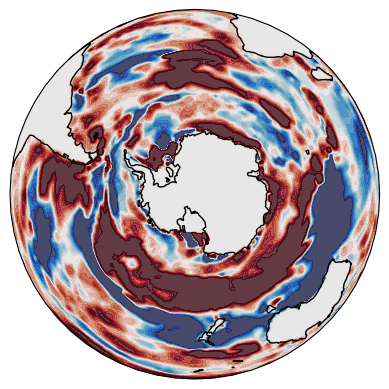

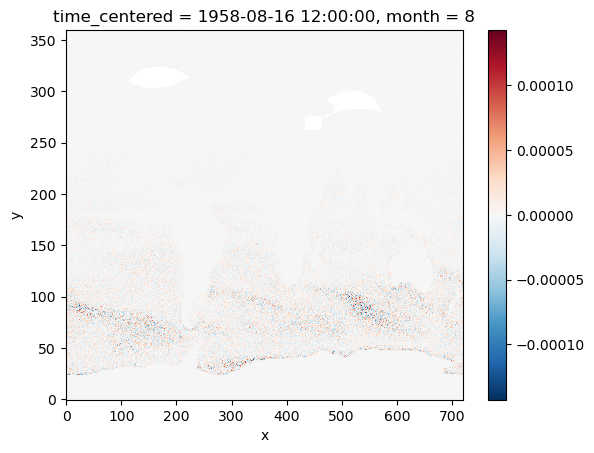

In [125]:
cflx_anom = cflx - cflx.mean(dim='year')
cflx_reg_anom = cflx_reg - cflx_reg.mean(dim='year')

proj = ccrs.Orthographic(central_latitude=-90)
levs = np.arange(-20,21,2)
colmap = lighten(cmo.balance, alpha=0.8)

plt.figure()
ax1 = plt.subplot(projection=proj)
ax1.contourf(cflx_reg_anom.coords['lon'], cflx_reg_anom.coords['lat'], cflx_reg_anom.isel(year=1, month=8), \
             transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
ax1.add_feature(cfeature.COASTLINE)

### make sure that the monthly anomaly has been calculated properly... there should be all zeros in next figure
plt.figure()
cflx_reg_anom.sel(month=8).mean(dim='year').plot()


## prepare data for EOFs

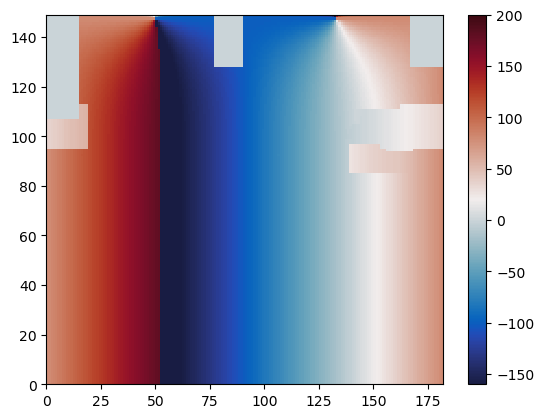

In [126]:
plt.figure()
plt.pcolormesh(cflx_anom.coords['lon'], cmap=cmo.balance, vmin=-160, vmax=200)
plt.colorbar()


In [127]:
cflx_anom = cflx_anom.roll(x=30, roll_coords=True)

# fix the native grid so that all longitudes are positive
lon = cflx_anom.coords['lon']
lat = cflx_anom.coords['lat']
lon_positive = lon.where(lon >= 0.0, lon + 360.0)
print(lon_positive[0,0])

cflx_anom = cflx_anom.assign_coords({"lon":lon_positive})


<xarray.DataArray 'lon' ()> Size: 4B
array(22.000566, dtype=float32)
Coordinates:
    lat      float32 4B -78.19
    lon      float32 4B 22.0


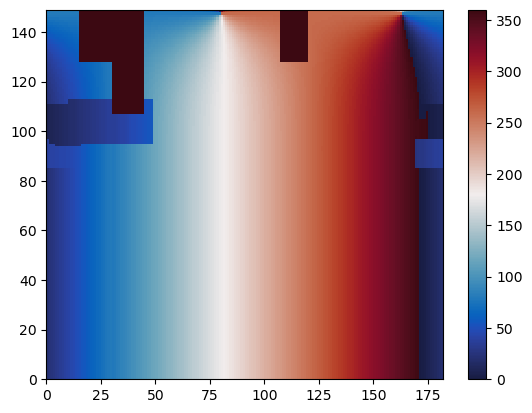

In [128]:
plt.figure()
plt.pcolormesh(cflx_anom.coords['lon'], cmap=cmo.balance, vmin=0, vmax=360)
plt.colorbar()

## Select regions of interest

/jobfs/136526757.gadi-pbs/ipykernel_658930/563712934.py:31: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(spac_cflx_anom.coords['lon'], spac_cflx_anom.coords['lat'], spac_cflx_anom.sel(year=1970.5, month=8))
/jobfs/136526757.gadi-pbs/ipykernel_658930/563712934.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(sind_cflx_anom.coords['lon'], sind_cflx_anom.coords['lat'], sind_cflx_anom.sel(year=1970.5, month=8))
/jobfs/136526757.gadi-pbs/ipykernel_658930/563712934.py:43: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, 

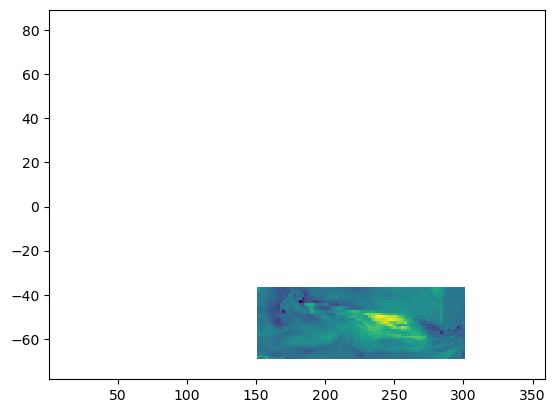

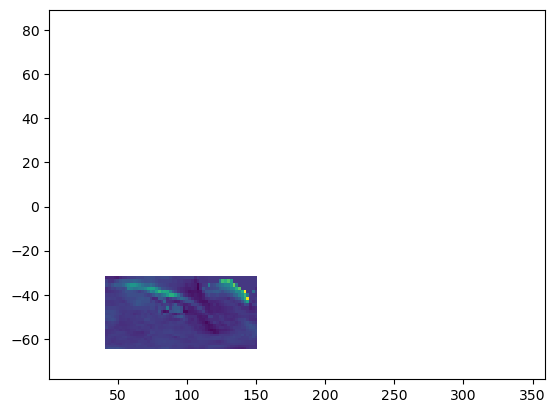

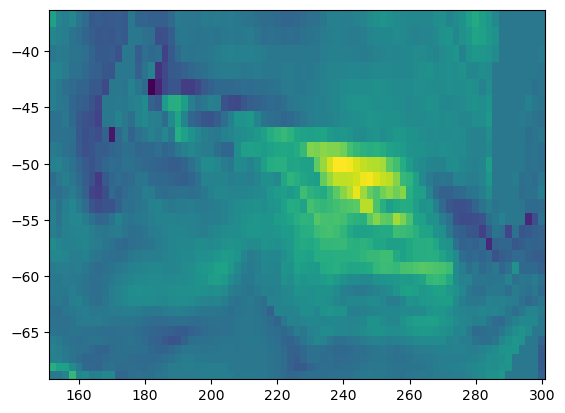

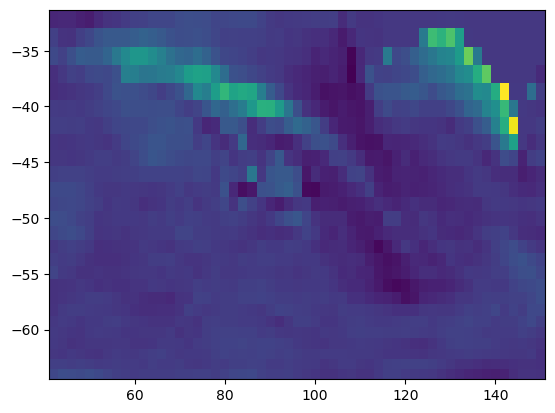

In [129]:
plon1 = 150.5; plon2 = 300.5
plat1 = -69.5; plat2 = -35.5

ilon1 = 40.5; ilon2 = 150.5
ilat1 = -64.5; ilat2 = -30.5

# add the regularly spaced coordinate values to the x and y dimensions for selection of boxes
lon_norm = ds_out.coords['lon'][0,:].values
lon_norm[lon_norm < 0] += 360
lat_norm = ds_out.coords['lat'][:,1].values
cflx_reg_month_anomaly = cflx_reg_anom.assign_coords({"x":lon_norm, "y":lat_norm})
cflx_reg_month_anomaly = cflx_reg_month_anomaly.sortby(cflx_reg_month_anomaly.x)
cflx_reg_month_anomaly = cflx_reg_month_anomaly.drop_vars(['lon','lat'])

spac_cflx_reg_anom = cflx_reg_month_anomaly.sel(x=slice(plon1,plon2), y=slice(plat1,plat2))
sind_cflx_reg_anom = cflx_reg_month_anomaly.sel(x=slice(ilon1,ilon2), y=slice(ilat1,ilat2))


# for the native MLD data
spac_cflx_anom = cflx_anom.where((cflx_anom.coords['lon'] > plon1) & (cflx_anom.coords['lon'] < plon2), other=np.nan)
spac_cflx_anom = spac_cflx_anom.where((spac_cflx_anom.coords['lat'] > plat1) & (spac_cflx_anom.coords['lat'] < plat2), other=np.nan)
spac_area = area.where((cflx_anom.coords['lon'] > plon1) & (cflx_anom.coords['lon'] < plon2), other=np.nan)
spac_area = spac_area.where((spac_cflx_anom.coords['lat'] > plat1) & (spac_cflx_anom.coords['lat'] < plat2), other=np.nan)

sind_cflx_anom = cflx_anom.where((cflx_anom.coords['lon'] > ilon1) & (cflx_anom.coords['lon'] < ilon2), other=np.nan)
sind_cflx_anom = sind_cflx_anom.where((sind_cflx_anom.coords['lat'] > ilat1) & (sind_cflx_anom.coords['lat'] < ilat2), other=np.nan)
sind_area = area.where((cflx_anom.coords['lon'] > ilon1) & (cflx_anom.coords['lon'] < ilon2), other=np.nan)
sind_area = sind_area.where((sind_cflx_anom.coords['lat'] > ilat1) & (sind_cflx_anom.coords['lat'] < ilat2), other=np.nan)

plt.figure()
plt.pcolormesh(spac_cflx_anom.coords['lon'], spac_cflx_anom.coords['lat'], spac_cflx_anom.sel(year=1970.5, month=8))
plt.figure()
plt.pcolormesh(sind_cflx_anom.coords['lon'], sind_cflx_anom.coords['lat'], sind_cflx_anom.sel(year=1970.5, month=8))

spac_cflx_anom = spac_cflx_anom.where(~np.isnan(spac_cflx_anom), drop=True)
sind_cflx_anom = sind_cflx_anom.where(~np.isnan(sind_cflx_anom), drop=True)
spac_area = spac_area.where(~np.isnan(spac_area), drop=True)
sind_area = sind_area.where(~np.isnan(sind_area), drop=True)

plt.figure()
plt.pcolormesh(spac_cflx_anom.coords['lon'], spac_cflx_anom.coords['lat'], spac_cflx_anom.sel(year=1970.5, month=8))
plt.figure()
plt.pcolormesh(sind_cflx_anom.coords['lon'], sind_cflx_anom.coords['lat'], sind_cflx_anom.sel(year=1970.5, month=8))


## blend years and months into one time dimension

In [130]:
%%time

from datetime import datetime, timedelta

start_date = datetime(1958, 1, 1)
end_date = datetime(2022, 12, 31)
time = pd.date_range(start=start_date, end=end_date, freq="MS") + pd.DateOffset(days=14)
time

# blend years and months into one time dimension
spac_cflx_anom = spac_cflx_anom.stack(time=("year", "month"))
sind_cflx_anom = sind_cflx_anom.stack(time=("year", "month"))
spac_cflx_anom = spac_cflx_anom.drop_vars(['year', 'month', 'time_centered'])
sind_cflx_anom = sind_cflx_anom.drop_vars(['year', 'month', 'time_centered'])
spac_cflx_anom = spac_cflx_anom.assign_coords(time=time)
sind_cflx_anom = sind_cflx_anom.assign_coords(time=time)

spac_cflx_reg_anom = spac_cflx_reg_anom.stack(time=("year", "month"))
sind_cflx_reg_anom = sind_cflx_reg_anom.stack(time=("year", "month"))
spac_cflx_reg_anom = spac_cflx_reg_anom.drop_vars(['year', 'month', 'time_centered'])
sind_cflx_reg_anom = sind_cflx_reg_anom.drop_vars(['year', 'month', 'time_centered'])
spac_cflx_reg_anom = spac_cflx_reg_anom.assign_coords(time=time)
sind_cflx_reg_anom = sind_cflx_reg_anom.assign_coords(time=time)


CPU times: user 29.9 ms, sys: 576 μs, total: 30.5 ms
Wall time: 28.7 ms


## Hovmoller of MLD in regions

Text(0, 0.5, 'MLD anomaly (m)')

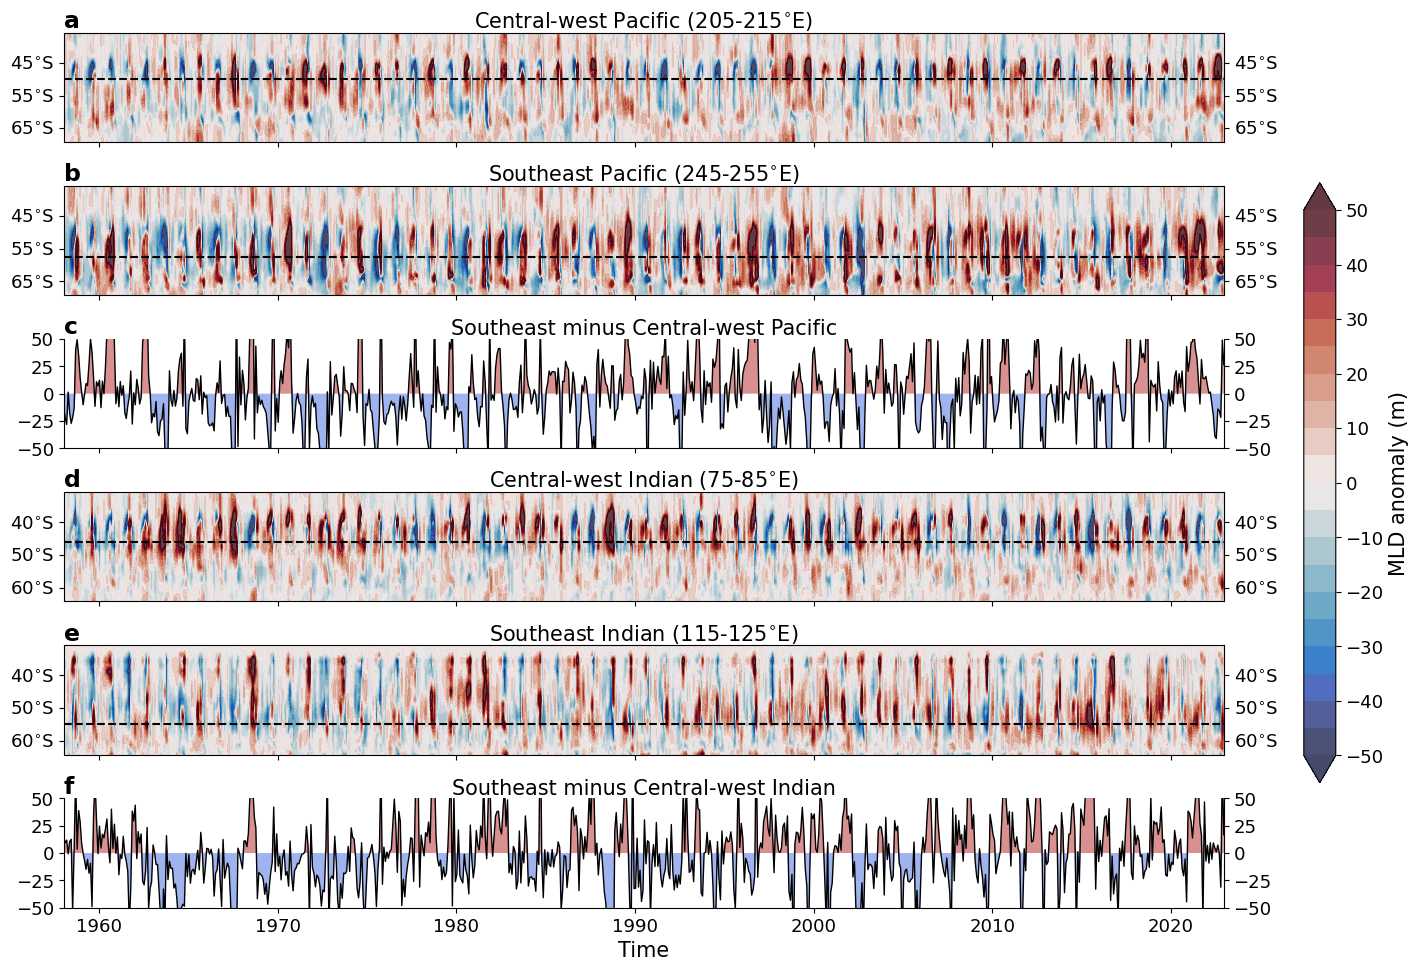

In [131]:
### chose longitudes
xpac_SE = 250.0
xpac_SW = 210.0
xind_SE = 120.0
xind_SW = 80.0
### chose latitudes
ypac_SE = -57.5
ypac_SW = -50.0
yind_SE = -55.0
yind_SW = -46.0
# set the window over which the longitudes and latitudes will be averaged for plotting
dlon = 10.0
dlat = 5.0


### calculate the hovmollers
hov_pac_SE = spac_cflx_reg_anom.sel(x=slice(xpac_SE-dlon*0.5,xpac_SE+dlon*0.5)).mean(dim="x")
hov_pac_SW = spac_cflx_reg_anom.sel(x=slice(xpac_SW-dlon*0.5,xpac_SW+dlon*0.5)).mean(dim="x")
hov_ind_SE = sind_cflx_reg_anom.sel(x=slice(xind_SE-dlon*0.5,xind_SE+dlon*0.5)).mean(dim="x")
hov_ind_SW = sind_cflx_reg_anom.sel(x=slice(xind_SW-dlon*0.5,xind_SW+dlon*0.5)).mean(dim="x")

### calculate the timeseries
ts_pac_SE = hov_pac_SE.sel(y=slice(ypac_SE-dlat*0.5,ypac_SE+dlat*0.5)).mean(dim=["y"])
ts_pac_SW = hov_pac_SW.sel(y=slice(ypac_SW-dlat*0.5,ypac_SW+dlat*0.5)).mean(dim=["y"])
ts_ind_SE = hov_ind_SE.sel(y=slice(yind_SE-dlat*0.5,yind_SE+dlat*0.5)).mean(dim=["y"])
ts_ind_SW = hov_ind_SW.sel(y=slice(yind_SW-dlat*0.5,yind_SW+dlat*0.5)).mean(dim=["y"])

levs = np.arange(-50,51,5)
colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15
wid = 1.0
cols = ['firebrick', 'royalblue', 'k']
lwid = [0.5, 0.5, 1.0]

fig = plt.figure(figsize=(16,10), facecolor='w')
gs = GridSpec(6,1)

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])
ax3 = plt.subplot(gs[2])
ax4 = plt.subplot(gs[3])
ax5 = plt.subplot(gs[4])
ax6 = plt.subplot(gs[5])

ax3.spines['top'].set_visible(False)
ax6.spines['top'].set_visible(False)

ax1.tick_params(labelsize=fstic, labelbottom=False, labelright=True, right=True)
ax2.tick_params(labelsize=fstic, labelbottom=False, labelright=True, right=True)
ax3.tick_params(labelsize=fstic, labelbottom=False, labelright=True, right=True)
ax4.tick_params(labelsize=fstic, labelbottom=False, labelright=True, right=True)
ax5.tick_params(labelsize=fstic, labelbottom=False, labelright=True, right=True)
ax6.tick_params(labelsize=fstic, labelright=True, right=True)

p1 = ax1.contourf(time, spac_cflx_reg_anom.coords['y'], hov_pac_SW, cmap=colmap, levels=levs, extend='both')
ax2.contourf(time, spac_cflx_reg_anom.coords['y'], hov_pac_SE, cmap=colmap, levels=levs, extend='both')

ax1.plot(time, np.ones(len(time))*ypac_SW, 'k--')
ax2.plot(time, np.ones(len(time))*ypac_SE, 'k--')
#ax3.plot(time, ts_pac_SE, color=cols[0], linewidth=lwid[0], alpha=0.25)
#ax3.plot(time, ts_pac_SW, color=cols[1], linewidth=lwid[1], alpha=0.25)
ax3.plot(time, ts_pac_SE - ts_pac_SW, color=cols[2], linewidth=lwid[2])

ax3.fill_between(time, (ts_pac_SE - ts_pac_SW).where((ts_pac_SE - ts_pac_SW) > 0.0, other=0.0), alpha=0.5, facecolor=cols[0])
ax3.fill_between(time, (ts_pac_SE - ts_pac_SW).where((ts_pac_SE - ts_pac_SW) < 0.0, other=0.0), alpha=0.5, facecolor=cols[1])

ax4.contourf(time, sind_cflx_reg_anom.coords['y'], hov_ind_SW, cmap=colmap, levels=levs, extend='both')
ax5.contourf(time, sind_cflx_reg_anom.coords['y'], hov_ind_SE, cmap=colmap, levels=levs, extend='both')

ax4.plot(time, np.ones(len(time))*yind_SW, 'k--')
ax5.plot(time, np.ones(len(time))*yind_SE, 'k--')
#ax6.plot(time, ts_ind_SE, color=cols[0], linewidth=lwid[0], alpha=0.25)
#ax6.plot(time, ts_ind_SW, color=cols[1], linewidth=lwid[1], alpha=0.25)
ax6.plot(time, ts_ind_SE - ts_ind_SW, color=cols[2], linewidth=lwid[2])

ax6.fill_between(time, (ts_ind_SE - ts_ind_SW).where((ts_ind_SE - ts_ind_SW) > 0.0, other=0.0), alpha=0.5, facecolor=cols[0])
ax6.fill_between(time, (ts_ind_SE - ts_ind_SW).where((ts_ind_SE - ts_ind_SW) < 0.0, other=0.0), alpha=0.5, facecolor=cols[1])

ax3.set_yticks(np.arange(-1,1.1,0.5)*50)
ax3.set_ylim(-50,50)
ax6.set_yticks(np.arange(-1,1.1,0.5)*50)
ax6.set_ylim(-50,50)

ax1.set_yticks(np.arange(-65,-39,10), ['65$^{\circ}$S', '55$^{\circ}$S', '45$^{\circ}$S'])
ax2.set_yticks(np.arange(-65,-39,10), ['65$^{\circ}$S', '55$^{\circ}$S', '45$^{\circ}$S'])
ax4.set_yticks(np.arange(-60,-34,10), ['60$^{\circ}$S', '50$^{\circ}$S', '40$^{\circ}$S'])
ax5.set_yticks(np.arange(-60,-34,10), ['60$^{\circ}$S', '50$^{\circ}$S', '40$^{\circ}$S'])

ax3.set_xlim(time[0], time[-1])
ax6.set_xlim(time[0], time[-1])
ax6.set_xlabel("Time", fontsize=fslab)

plt.subplots_adjust(right=0.85, bottom=0.075, top=0.95, hspace=0.40)

xx = 0.0; yy = 1.00
plt.text(xx,yy,'a', fontsize=fslab+2, fontweight='bold', ha='left', va='bottom', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontsize=fslab+2, fontweight='bold', ha='left', va='bottom', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontsize=fslab+2, fontweight='bold', ha='left', va='bottom', transform=ax3.transAxes)
plt.text(xx,yy,'d', fontsize=fslab+2, fontweight='bold', ha='left', va='bottom', transform=ax4.transAxes)
plt.text(xx,yy,'e', fontsize=fslab+2, fontweight='bold', ha='left', va='bottom', transform=ax5.transAxes)
plt.text(xx,yy,'f', fontsize=fslab+2, fontweight='bold', ha='left', va='bottom', transform=ax6.transAxes)

xx = 0.5; yy = 1.00
plt.text(xx,yy,'Central-west Pacific (%i-%i$^{\circ}$E)'%(xpac_SW-dlon*0.5, xpac_SW+dlon*0.5), fontsize=fslab, ha='center', va='bottom', transform=ax1.transAxes)
plt.text(xx,yy,'Southeast Pacific (%i-%i$^{\circ}$E)'%(xpac_SE-dlon*0.5, xpac_SE+dlon*0.5), fontsize=fslab, ha='center', va='bottom', transform=ax2.transAxes)
plt.text(xx,yy,'Southeast minus Central-west Pacific', fontsize=fslab, ha='center', va='bottom', transform=ax3.transAxes)
plt.text(xx,yy,'Central-west Indian (%i-%i$^{\circ}$E)'%(xind_SW-dlon*0.5, xind_SW+dlon*0.5), fontsize=fslab, ha='center', va='bottom', transform=ax4.transAxes)
plt.text(xx,yy,'Southeast Indian (%i-%i$^{\circ}$E)'%(xind_SE-dlon*0.5, xind_SE+dlon*0.5), fontsize=fslab, ha='center', va='bottom', transform=ax5.transAxes)
plt.text(xx,yy,'Southeast minus Central-west Indian', fontsize=fslab, ha='center', va='bottom', transform=ax6.transAxes)



cbax = fig.add_axes([0.9,0.2,0.02,0.6])
cbar = plt.colorbar(p1, cax=cbax, orientation='vertical', ticks=levs[::2])
cbar.ax.tick_params(labelsize=fstic)
cbar.ax.set_ylabel('MLD anomaly (m)', fontsize=fslab)

## Compute the EOFs for MLD in the South Indian and South Pacific regions

In [132]:
%%time

### Single Value Decomposition on Pacific data

weights = spac_area.mean(dim='year') / spac_area.mean(dim='year').sum()
W_pac = weights**0.5
X = spac_cflx_anom * W_pac
Xpac = X.stack(space=("y","x"))

U, S, V = np.linalg.svd(Xpac.T.values, full_matrices=False)

### reconstruct the dimensions of the original data

U_ = Xpac.T * 0 + U
U_pac = U_.unstack('space') * W_pac**(-1)
U_pac = U_pac.rename({"time":"mode"})
U_pac = U_pac.assign_coords({"mode":np.arange(len(S))})

S_pac = xr.DataArray(
    S,
    dims=["mode"],
    coords={"mode":np.arange(len(S))}
)

V_pac = xr.DataArray(
    V.T,
    dims=["time","mode"],
    coords={
        "time":Xpac.coords['time'].values,
        "mode":np.arange(len(S))
    }
)

# variance explained
S2_pac = S_pac**2.0
VE_pac = S2_pac / S2_pac.sum()

print(np.shape(Xpac.T))
print(np.shape(U_pac))
print(np.shape(S_pac))
print(np.shape(V_pac))
print(np.shape(VE_pac))

(2175, 780)
(780, 29, 75)
(780,)
(780, 780)
(780,)
CPU times: user 1.46 s, sys: 17 ms, total: 1.47 s
Wall time: 1.47 s


In [133]:
### Single Value Decomposition on Indian data

weights = sind_area.mean(dim='year') / sind_area.mean(dim='year').sum()
W_ind = weights**0.5
X = sind_cflx_anom * W_ind
Xind = X.stack(space=("y","x"))

U, S, V = np.linalg.svd(Xind.T.values, full_matrices=False)

### reconstruct the dimensions of the original data

U_ = Xind.T * 0 + U
U_ind = U_.unstack('space') * W_ind**(-1)
U_ind = U_ind.rename({"time":"mode"})
U_ind = U_ind.assign_coords({"mode":np.arange(len(S))})

S_ind = xr.DataArray(
    S,
    dims=["mode"],
    coords={"mode":np.arange(len(S))}
)

V_ind = xr.DataArray(
    V.T,
    dims=["time","mode"],
    coords={
        "time":Xind.coords['time'].values,
        "mode":np.arange(len(S))
    }
)

# variance explained
S2_ind = S_ind**2.0
VE_ind = S2_ind / S2_ind.sum()

print(np.shape(Xind.T))
print(np.shape(U_ind))
print(np.shape(S_ind))
print(np.shape(V_ind))
print(np.shape(VE_ind))

(1482, 780)
(780, 26, 57)
(780,)
(780, 780)
(780,)


## Have a look

Total variance explained in Indian by first 2 modes = 0.38952428
Total variance explained in Pacific by first 2 modes = 0.41079193


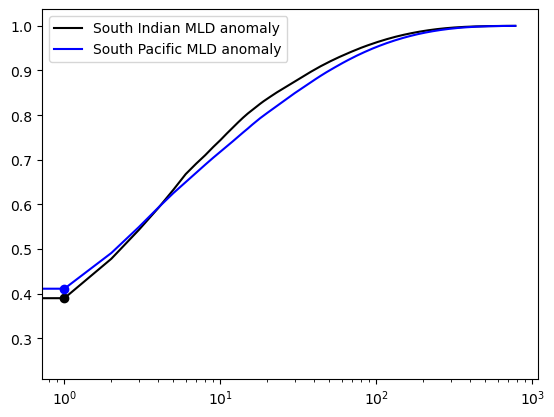

In [134]:
imodes = 1
print("Total variance explained in Indian by first %i modes ="%(imodes+1), VE_ind.cumsum().sel(mode=imodes).values)
print("Total variance explained in Pacific by first %i modes ="%(imodes+1), VE_pac.cumsum().sel(mode=imodes).values)

plt.figure()
plt.plot(np.arange(len(VE_ind)), VE_ind.cumsum(), color='k', label="South Indian MLD anomaly")
plt.plot(np.arange(len(VE_pac)), VE_pac.cumsum(), color='b', label="South Pacific MLD anomaly")
plt.scatter(imodes, VE_ind.cumsum().sel(mode=imodes), marker='o', color='k')
plt.scatter(imodes, VE_pac.cumsum().sel(mode=imodes), marker='o', color='b')
plt.legend()
plt.xscale('log')

## Regrid the EOFs

In [135]:
%%time
### regrid the EOFs to a regular grid

target_grid = xr.Dataset(
    {
        "lat": (["lat"], np.arange(plat1,plat2+0.5,0.5)),
        "lon": (["lon"], np.arange(plon1,plon2+0.5,0.5)),
    }
)

regridder = xe.Regridder(U_pac, target_grid, 'bilinear', ignore_degenerate=True, periodic=True)
U_pac_reg = regridder(U_pac)

target_grid = xr.Dataset(
    {
        "lat": (["lat"], np.arange(ilat1,ilat2+0.5,0.5)),
        "lon": (["lon"], np.arange(ilon1,ilon2+0.5,0.5)),
    }
)

regridder = xe.Regridder(U_ind, target_grid, 'bilinear', ignore_degenerate=True, periodic=True)
U_ind_reg = regridder(U_ind)


CPU times: user 1.09 s, sys: 120 ms, total: 1.21 s
Wall time: 1.21 s


Text(0.05, 1.05, 'j')

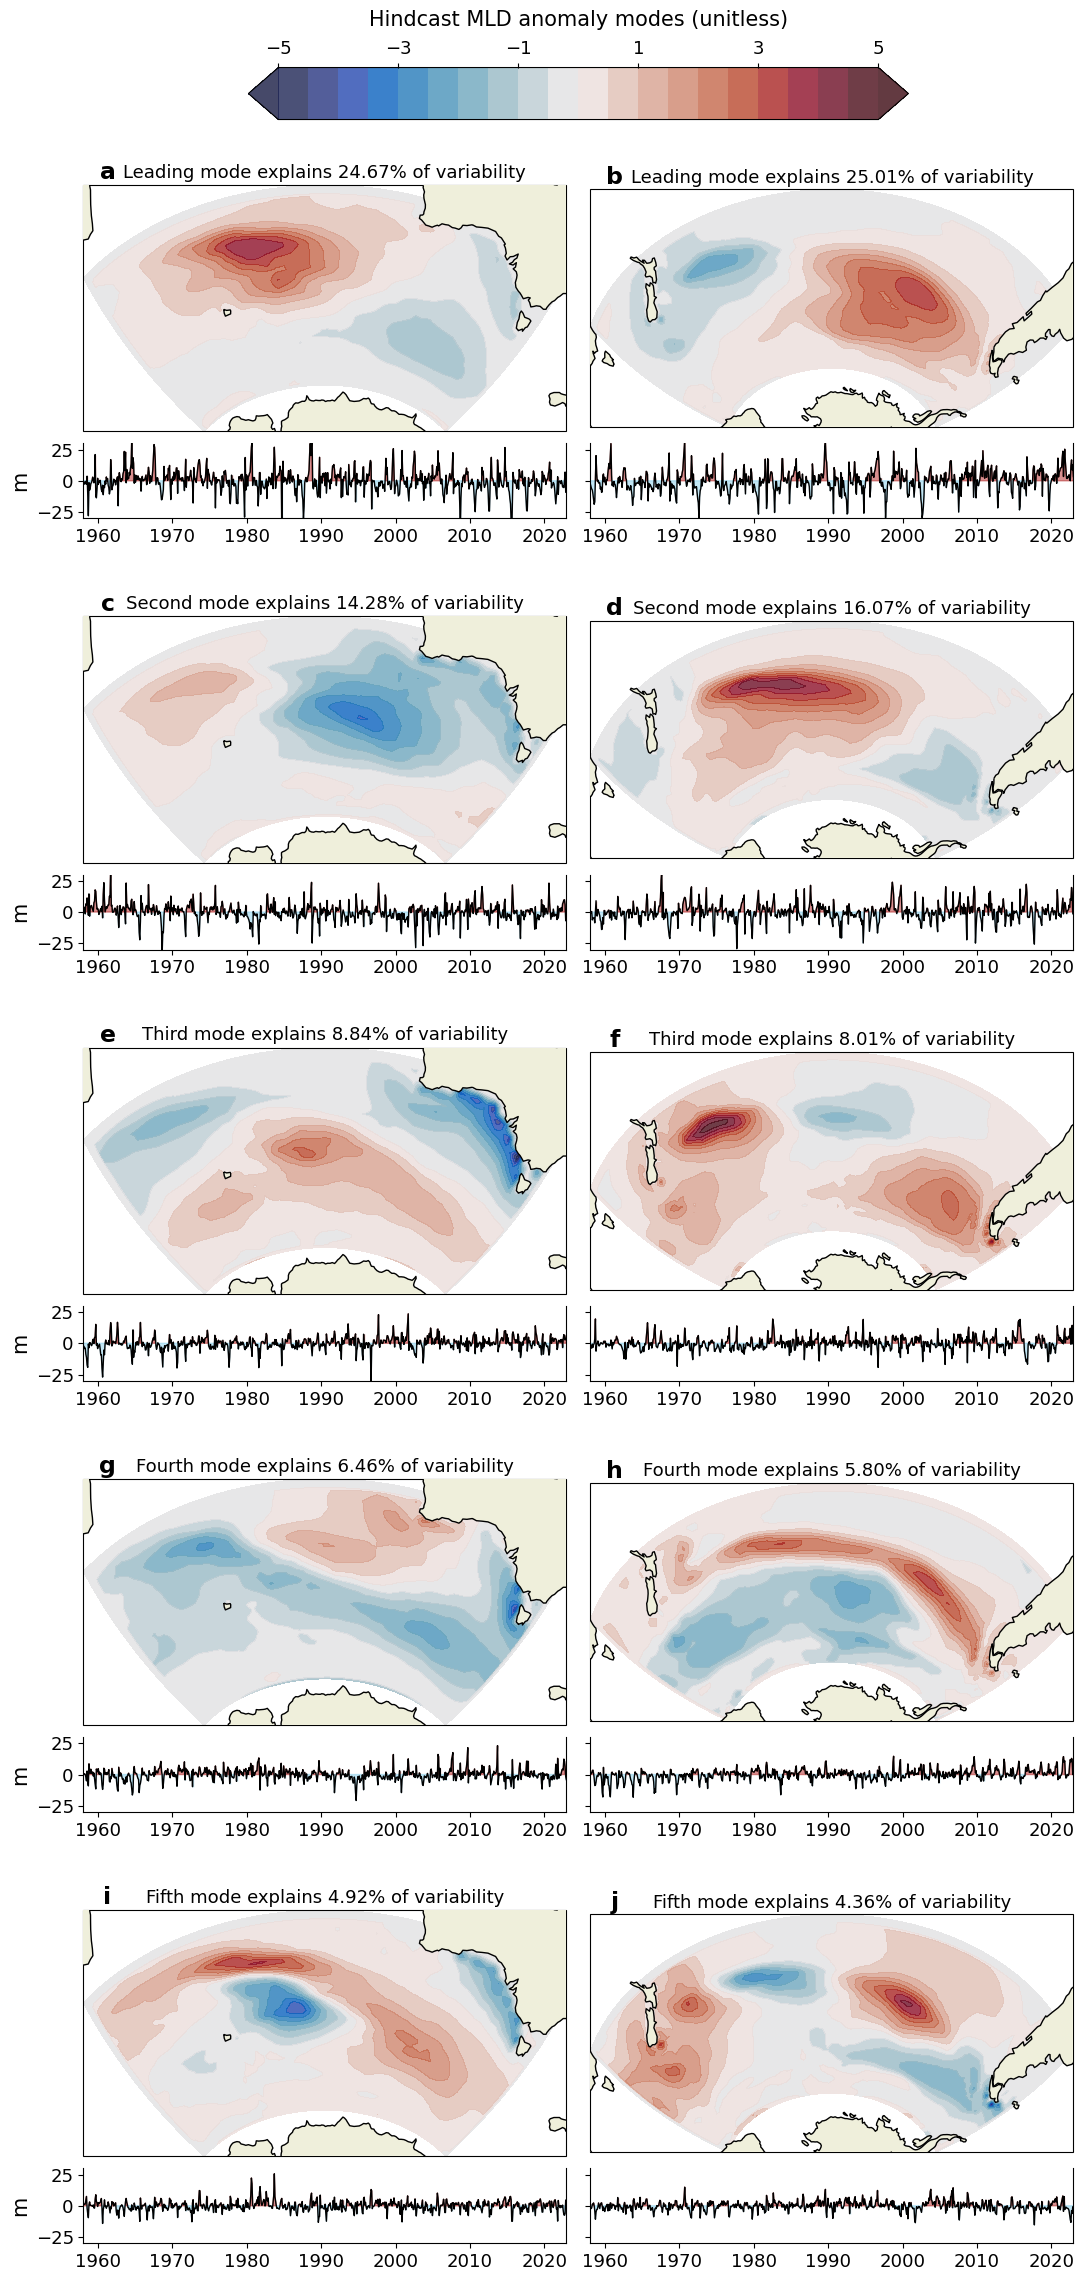

In [136]:

sind_proj = ccrs.Orthographic(central_latitude=ilat1+(ilat2-ilat1)*0.5, central_longitude=ilon1+(ilon2-ilon1)*0.5)
spac_proj = ccrs.Orthographic(central_latitude=ilat1+(ilat2-ilat1)*0.5, central_longitude=plon1+(plon2-plon1)*0.5)

paclons = U_pac_reg.coords['lon']
paclats = U_pac_reg.coords['lat']
indlons = U_ind_reg.coords['lon']
indlats = U_ind_reg.coords['lat']


levs = np.arange(-50,51,5)*1e-1
colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15
wid = 1.0

fig = plt.figure(figsize=(11,26), facecolor='w')
gs = GridSpec(25,2)

ax1 = plt.subplot(gs[0:3,0], projection=sind_proj)
ax2 = plt.subplot(gs[0:3,1], projection=spac_proj)
ax1p = plt.subplot(gs[3,0])
ax2p = plt.subplot(gs[3,1])
ax3 = plt.subplot(gs[5:8,0], projection=sind_proj)
ax4 = plt.subplot(gs[5:8,1], projection=spac_proj)
ax3p = plt.subplot(gs[8,0])
ax4p = plt.subplot(gs[8,1])
ax5 = plt.subplot(gs[10:13,0], projection=sind_proj)
ax6 = plt.subplot(gs[10:13,1], projection=spac_proj)
ax5p = plt.subplot(gs[13,0])
ax6p = plt.subplot(gs[13,1])
ax7 = plt.subplot(gs[15:18,0], projection=sind_proj)
ax8 = plt.subplot(gs[15:18,1], projection=spac_proj)
ax7p = plt.subplot(gs[18,0])
ax8p = plt.subplot(gs[18,1])
ax9 = plt.subplot(gs[20:23,0], projection=sind_proj)
ax10 = plt.subplot(gs[20:23,1], projection=spac_proj)
ax9p = plt.subplot(gs[23,0])
ax10p = plt.subplot(gs[23,1])

ax1.add_feature(cfeature.LAND, zorder=3)
ax1.add_feature(cfeature.COASTLINE, zorder=3)
ax2.add_feature(cfeature.LAND, zorder=3)
ax2.add_feature(cfeature.COASTLINE, zorder=3)
ax3.add_feature(cfeature.LAND, zorder=3)
ax3.add_feature(cfeature.COASTLINE, zorder=3)
ax4.add_feature(cfeature.LAND, zorder=3)
ax4.add_feature(cfeature.COASTLINE, zorder=3)
ax5.add_feature(cfeature.LAND, zorder=3)
ax5.add_feature(cfeature.COASTLINE, zorder=3)
ax6.add_feature(cfeature.LAND, zorder=3)
ax6.add_feature(cfeature.COASTLINE, zorder=3)
ax7.add_feature(cfeature.LAND, zorder=3)
ax7.add_feature(cfeature.COASTLINE, zorder=3)
ax8.add_feature(cfeature.LAND, zorder=3)
ax8.add_feature(cfeature.COASTLINE, zorder=3)
ax9.add_feature(cfeature.LAND, zorder=3)
ax9.add_feature(cfeature.COASTLINE, zorder=3)
ax10.add_feature(cfeature.LAND, zorder=3)
ax10.add_feature(cfeature.COASTLINE, zorder=3)


p1 = ax1.contourf(indlons,indlats, U_ind_reg.sel(mode=0), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p2 = ax2.contourf(paclons,paclats, U_pac_reg.sel(mode=0), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Leading mode explains %.2f%% of variability'%(VE_ind.sel(mode=0).values*100), transform=ax1.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Leading mode explains %.2f%% of variability'%(VE_pac.sel(mode=0).values*100), transform=ax2.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=0) * V_ind.sel(mode=0))
tmp_pac = (S_pac.sel(mode=0) * V_pac.sel(mode=0))
ax1p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax2p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax1p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax1p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax2p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax2p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


imodes = 1 
p3 = ax3.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p4 = ax4.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Second mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax3.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Second mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax4.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax3p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax4p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax3p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax3p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax4p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax4p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)

imodes = 2 
p5 = ax5.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p6 = ax6.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes)+1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Third mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax5.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Third mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax6.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax5p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax6p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax5p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax5p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax6p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax6p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


imodes = 3 
p7 = ax7.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p8 = ax8.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes)+1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Fourth mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax7.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Fourth mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax8.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax7p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax8p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax7p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax7p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax8p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax8p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


imodes = 4 
p9 = ax9.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p10 = ax10.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Fifth mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax9.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Fifth mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax10.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax9p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax10p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax9p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax9p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax10p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax10p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


ax1p.spines['top'].set_visible(False)
ax2p.spines['top'].set_visible(False)
ax3p.spines['top'].set_visible(False)
ax4p.spines['top'].set_visible(False)
ax5p.spines['top'].set_visible(False)
ax6p.spines['top'].set_visible(False)
ax7p.spines['top'].set_visible(False)
ax8p.spines['top'].set_visible(False)
ax9p.spines['top'].set_visible(False)
ax10p.spines['top'].set_visible(False)

ax1p.tick_params(labelsize=fstic)
ax2p.tick_params(labelsize=fstic, labelleft=False)
ax3p.tick_params(labelsize=fstic)
ax4p.tick_params(labelsize=fstic,labelleft=False)
ax5p.tick_params(labelsize=fstic)
ax6p.tick_params(labelsize=fstic,labelleft=False)
ax7p.tick_params(labelsize=fstic)
ax8p.tick_params(labelsize=fstic,labelleft=False)
ax9p.tick_params(labelsize=fstic)
ax10p.tick_params(labelsize=fstic,labelleft=False)

ax1p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax2p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax3p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax4p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax5p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax6p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax7p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax8p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax9p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax10p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())

y1 = -30; y2 = 30
ax1p.set_ylim(y1,y2)
ax2p.set_ylim(y1,y2)
ax3p.set_ylim(y1,y2)
ax4p.set_ylim(y1,y2)
ax5p.set_ylim(y1,y2)
ax6p.set_ylim(y1,y2)
ax7p.set_ylim(y1,y2)
ax8p.set_ylim(y1,y2)
ax9p.set_ylim(y1,y2)
ax10p.set_ylim(y1,y2)

ax1p.set_ylabel("m", fontsize=fslab)
ax3p.set_ylabel("m", fontsize=fslab)
ax5p.set_ylabel("m", fontsize=fslab)
ax7p.set_ylabel("m", fontsize=fslab)
ax9p.set_ylabel("m", fontsize=fslab)

cbax = fig.add_axes([0.2,0.9,0.6,0.02])
cbar1 = plt.colorbar(p1, cax=cbax, orientation='horizontal', ticks=levs[::4])
cbar1.ax.tick_params(labelsize=fstic, labelbottom=False, bottom=False, labeltop=True, top=True)
cbar1.ax.set_xlabel('Hindcast MLD anomaly modes (unitless)', fontsize=fslab, labelpad=10)
cbar1.ax.xaxis.set_label_position('top')

plt.subplots_adjust(left=0.05, top=0.875, right=0.95, bottom=0.05, wspace=0.05, hspace=0.15)

xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,'d', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,'e', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,'f', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)
plt.text(xx,yy,'g', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax7.transAxes)
plt.text(xx,yy,'h', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax8.transAxes)
plt.text(xx,yy,'i', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax9.transAxes)
plt.text(xx,yy,'j', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax10.transAxes)


In [28]:
fig.savefig("/home/581/pjb581/analysis_samw/hindcast_mld_1958-2022_eofs.png", dpi=300)


In [137]:
%%time

# Pacific is positive then negative given spatial pattern of EOFs
I_pac_pos = ((S_pac.sel(mode=0) * V_pac.sel(mode=0).T + S_pac.sel(mode=1) * V_pac.sel(mode=1).T ) / 
            ((S_pac.sel(mode=0))**2 + (S_pac.sel(mode=1))**2)**0.5)
I_pac_neg = ((S_pac.sel(mode=0) * V_pac.sel(mode=0).T - S_pac.sel(mode=1) * V_pac.sel(mode=1).T ) / 
            ((S_pac.sel(mode=0))**2 + (S_pac.sel(mode=1))**2)**0.5)
# Indian is both negative given spatial pattern of EOFs
I_ind_pos = ((S_ind.sel(mode=0) * V_ind.sel(mode=0).T * (-1) + S_ind.sel(mode=1) * V_ind.sel(mode=1).T * (-1) ) / 
            ((S_ind.sel(mode=0))**2 + (S_ind.sel(mode=1))**2)**0.5)
I_ind_neg = ((S_ind.sel(mode=0) * V_ind.sel(mode=0).T * (-1) - S_ind.sel(mode=1) * V_ind.sel(mode=1).T * (-1) ) / 
            ((S_ind.sel(mode=0))**2 + (S_ind.sel(mode=1))**2)**0.5)

# Normalize
I_pac_pos = (I_pac_pos - I_pac_pos.mean()) / I_pac_pos.std()
I_pac_neg = (I_pac_neg - I_pac_neg.mean()) / I_pac_neg.std()
I_ind_pos = (I_ind_pos - I_ind_pos.mean()) / I_ind_pos.std()
I_ind_neg = (I_ind_neg - I_ind_neg.mean()) / I_ind_neg.std()

I_ind_pos.name = "I_MLD"
I_pac_pos.name = "I_MLD"
I_ind_neg.name = "I_MLD"
I_pac_neg.name = "I_MLD"

os.remove('/home/581/pjb581/analysis_samw/Ipos_ind_1958-2022.nc')
os.remove('/home/581/pjb581/analysis_samw/Ipos_pac_1958-2022.nc')
os.remove('/home/581/pjb581/analysis_samw/Ineg_ind_1958-2022.nc')
os.remove('/home/581/pjb581/analysis_samw/Ineg_pac_1958-2022.nc')

I_ind_pos.to_netcdf('/home/581/pjb581/analysis_samw/Ipos_ind_1958-2022.nc')
I_pac_pos.to_netcdf('/home/581/pjb581/analysis_samw/Ipos_pac_1958-2022.nc')
I_ind_neg.to_netcdf('/home/581/pjb581/analysis_samw/Ineg_ind_1958-2022.nc')
I_pac_neg.to_netcdf('/home/581/pjb581/analysis_samw/Ineg_pac_1958-2022.nc')


CPU times: user 53.6 ms, sys: 2.58 ms, total: 56.2 ms
Wall time: 71.3 ms


## Do the same now for 2005 to 2022

In [138]:
cflx_reg_anom = cflx_reg.sel(year=slice(2005,2023)) - cflx_reg.sel(year=slice(2005,2023)).mean(dim='year')
cflx_anom = cflx.sel(year=slice(2005,2023)) - cflx.sel(year=slice(2005,2023)).mean(dim='year')

cflx_anom = cflx_anom.roll(x=30, roll_coords=True)
# fix the native grid so that all longitudes are positive
lon = cflx_anom.coords['lon']
lat = cflx_anom.coords['lat']
lon_positive = lon.where(lon >= 0.0, lon + 360.0)
cflx_anom = cflx_anom.assign_coords({"lon":lon_positive})


# add the regularly spaced coordinate values to the x and y dimensions for selection of boxes
lon_norm = ds_out.coords['lon'][0,:].values
lon_norm[lon_norm < 0] += 360
lat_norm = ds_out.coords['lat'][:,1].values
cflx_reg_month_anomaly = cflx_reg_anom.assign_coords({"x":lon_norm, "y":lat_norm})
cflx_reg_month_anomaly = cflx_reg_month_anomaly.sortby(cflx_reg_month_anomaly.x)
cflx_reg_month_anomaly = cflx_reg_month_anomaly.drop_vars(['lon','lat'])
spac_cflx_reg_anom = cflx_reg_month_anomaly.sel(x=slice(plon1,plon2), y=slice(plat1,plat2))
sind_cflx_reg_anom = cflx_reg_month_anomaly.sel(x=slice(ilon1,ilon2), y=slice(ilat1,ilat2))


# for the native MLD data
spac_cflx_anom = cflx_anom.where((cflx_anom.coords['lon'] > plon1) & (cflx_anom.coords['lon'] < plon2), other=np.nan)
spac_cflx_anom = spac_cflx_anom.where((spac_cflx_anom.coords['lat'] > plat1) & (spac_cflx_anom.coords['lat'] < plat2), other=np.nan)
spac_area = area.where((cflx_anom.coords['lon'] > plon1) & (cflx_anom.coords['lon'] < plon2), other=np.nan)
spac_area = spac_area.where((spac_cflx_anom.coords['lat'] > plat1) & (spac_cflx_anom.coords['lat'] < plat2), other=np.nan)

sind_cflx_anom = cflx_anom.where((cflx_anom.coords['lon'] > ilon1) & (cflx_anom.coords['lon'] < ilon2), other=np.nan)
sind_cflx_anom = sind_cflx_anom.where((sind_cflx_anom.coords['lat'] > ilat1) & (sind_cflx_anom.coords['lat'] < ilat2), other=np.nan)
sind_area = area.where((cflx_anom.coords['lon'] > ilon1) & (cflx_anom.coords['lon'] < ilon2), other=np.nan)
sind_area = sind_area.where((sind_cflx_anom.coords['lat'] > ilat1) & (sind_cflx_anom.coords['lat'] < ilat2), other=np.nan)

spac_cflx_anom = spac_cflx_anom.where(~np.isnan(spac_cflx_anom), drop=True)
sind_cflx_anom = sind_cflx_anom.where(~np.isnan(sind_cflx_anom), drop=True)
spac_area = spac_area.where(~np.isnan(spac_area), drop=True)
sind_area = sind_area.where(~np.isnan(sind_area), drop=True)


from datetime import datetime, timedelta

start_date = datetime(2005, 1, 1)
end_date = datetime(2022, 12, 31)
time = pd.date_range(start=start_date, end=end_date, freq="MS") + pd.DateOffset(days=14)
time

# blend years and months into one time dimension
spac_cflx_anom = spac_cflx_anom.stack(time=("year", "month"))
sind_cflx_anom = sind_cflx_anom.stack(time=("year", "month"))
spac_cflx_anom = spac_cflx_anom.drop_vars(['year', 'month', 'time_centered'])
sind_cflx_anom = sind_cflx_anom.drop_vars(['year', 'month', 'time_centered'])
spac_cflx_anom = spac_cflx_anom.assign_coords(time=time)
sind_cflx_anom = sind_cflx_anom.assign_coords(time=time)
spac_cflx_reg_anom = spac_cflx_reg_anom.stack(time=("year", "month"))
sind_cflx_reg_anom = sind_cflx_reg_anom.stack(time=("year", "month"))
spac_cflx_reg_anom = spac_cflx_reg_anom.drop_vars(['year', 'month', 'time_centered'])
sind_cflx_reg_anom = sind_cflx_reg_anom.drop_vars(['year', 'month', 'time_centered'])
spac_cflx_reg_anom = spac_cflx_reg_anom.assign_coords(time=time)
sind_cflx_reg_anom = sind_cflx_reg_anom.assign_coords(time=time)


In [139]:
%%time

### Single Value Decomposition on Pacific data

weights = spac_area.mean(dim='year') / spac_area.mean(dim='year').sum()
W_pac = weights**0.5
X = spac_cflx_anom * W_pac
Xpac = X.stack(space=("y","x"))

U, S, V = np.linalg.svd(Xpac.T.values, full_matrices=False)

### reconstruct the dimensions of the original data

U_ = Xpac.T * 0 + U
U_pac = U_.unstack('space') * W_pac**(-1)
U_pac = U_pac.rename({"time":"mode"})
U_pac = U_pac.assign_coords({"mode":np.arange(len(S))})

S_pac = xr.DataArray(
    S,
    dims=["mode"],
    coords={"mode":np.arange(len(S))}
)

V_pac = xr.DataArray(
    V.T,
    dims=["time","mode"],
    coords={
        "time":Xpac.coords['time'].values,
        "mode":np.arange(len(S))
    }
)

# variance explained
S2_pac = S_pac**2.0
VE_pac = S2_pac / S2_pac.sum()

print(np.shape(Xpac.T))
print(np.shape(U_pac))
print(np.shape(S_pac))
print(np.shape(V_pac))
print(np.shape(VE_pac))

(2175, 216)
(216, 29, 75)
(216,)
(216, 216)
(216,)
CPU times: user 75.4 ms, sys: 6.47 ms, total: 81.8 ms
Wall time: 79.3 ms


In [140]:
### Single Value Decomposition on Indian data

weights = sind_area.mean(dim='year') / sind_area.mean(dim='year').sum()
W_ind = weights**0.5
X = sind_cflx_anom * W_ind
Xind = X.stack(space=("y","x"))

U, S, V = np.linalg.svd(Xind.T.values, full_matrices=False)

### reconstruct the dimensions of the original data

U_ = Xind.T * 0 + U
U_ind = U_.unstack('space') * W_ind**(-1)
U_ind = U_ind.rename({"time":"mode"})
U_ind = U_ind.assign_coords({"mode":np.arange(len(S))})

S_ind = xr.DataArray(
    S,
    dims=["mode"],
    coords={"mode":np.arange(len(S))}
)

V_ind = xr.DataArray(
    V.T,
    dims=["time","mode"],
    coords={
        "time":Xind.coords['time'].values,
        "mode":np.arange(len(S))
    }
)

# variance explained
S2_ind = S_ind**2.0
VE_ind = S2_ind / S2_ind.sum()

print(np.shape(Xind.T))
print(np.shape(U_ind))
print(np.shape(S_ind))
print(np.shape(V_ind))
print(np.shape(VE_ind))

(1482, 216)
(216, 26, 57)
(216,)
(216, 216)
(216,)


Total variance explained in Indian by first 2 modes = 0.4200996
Total variance explained in Pacific by first 2 modes = 0.40953976


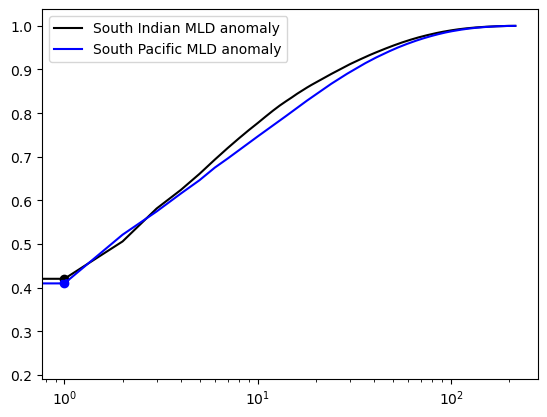

In [141]:
imodes = 1
print("Total variance explained in Indian by first %i modes ="%(imodes+1), VE_ind.cumsum().sel(mode=imodes).values)
print("Total variance explained in Pacific by first %i modes ="%(imodes+1), VE_pac.cumsum().sel(mode=imodes).values)

plt.figure()
plt.plot(np.arange(len(VE_ind)), VE_ind.cumsum(), color='k', label="South Indian MLD anomaly")
plt.plot(np.arange(len(VE_pac)), VE_pac.cumsum(), color='b', label="South Pacific MLD anomaly")
plt.scatter(imodes, VE_ind.cumsum().sel(mode=imodes), marker='o', color='k')
plt.scatter(imodes, VE_pac.cumsum().sel(mode=imodes), marker='o', color='b')
plt.legend()
plt.xscale('log')

In [142]:
%%time
### regrid the EOFs to a regular grid

target_grid = xr.Dataset(
    {
        "lat": (["lat"], np.arange(plat1,plat2+0.5,0.5)),
        "lon": (["lon"], np.arange(plon1,plon2+0.5,0.5)),
    }
)

regridder = xe.Regridder(U_pac, target_grid, 'bilinear', ignore_degenerate=True, periodic=True)
U_pac_reg = regridder(U_pac)

target_grid = xr.Dataset(
    {
        "lat": (["lat"], np.arange(ilat1,ilat2+0.5,0.5)),
        "lon": (["lon"], np.arange(ilon1,ilon2+0.5,0.5)),
    }
)

regridder = xe.Regridder(U_ind, target_grid, 'bilinear', ignore_degenerate=True, periodic=True)
U_ind_reg = regridder(U_ind)


CPU times: user 1.07 s, sys: 1.6 ms, total: 1.07 s
Wall time: 1.06 s


Text(0.05, 1.05, 'j')

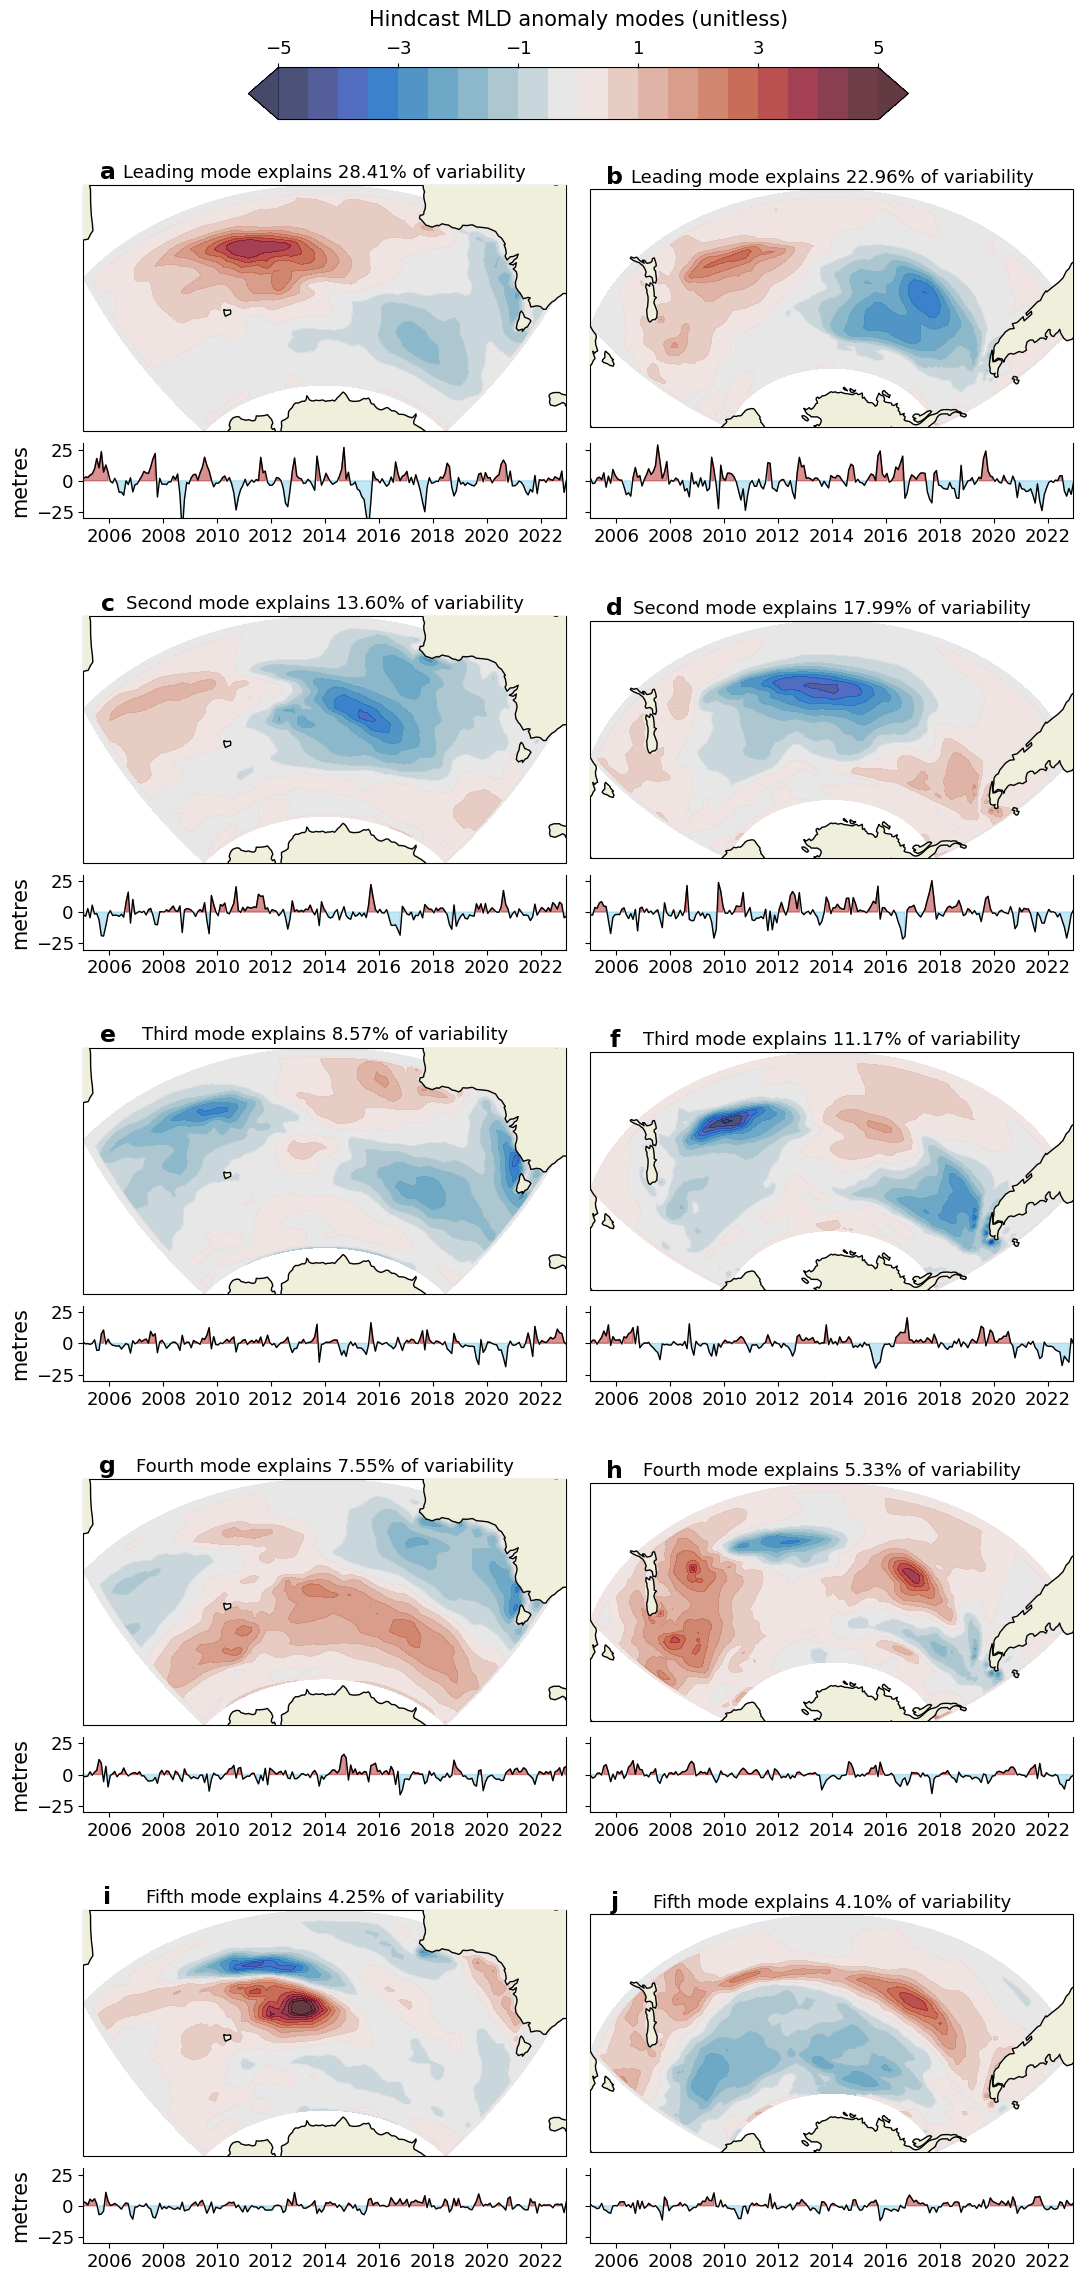

In [143]:

sind_proj = ccrs.Orthographic(central_latitude=ilat1+(ilat2-ilat1)*0.5, central_longitude=ilon1+(ilon2-ilon1)*0.5)
spac_proj = ccrs.Orthographic(central_latitude=ilat1+(ilat2-ilat1)*0.5, central_longitude=plon1+(plon2-plon1)*0.5)

paclons = U_pac_reg.coords['lon']
paclats = U_pac_reg.coords['lat']
indlons = U_ind_reg.coords['lon']
indlats = U_ind_reg.coords['lat']


levs = np.arange(-50,51,5)*1e-1
colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15
wid = 1.0

fig = plt.figure(figsize=(11,26), facecolor='w')
gs = GridSpec(25,2)

ax1 = plt.subplot(gs[0:3,0], projection=sind_proj)
ax2 = plt.subplot(gs[0:3,1], projection=spac_proj)
ax1p = plt.subplot(gs[3,0])
ax2p = plt.subplot(gs[3,1])
ax3 = plt.subplot(gs[5:8,0], projection=sind_proj)
ax4 = plt.subplot(gs[5:8,1], projection=spac_proj)
ax3p = plt.subplot(gs[8,0])
ax4p = plt.subplot(gs[8,1])
ax5 = plt.subplot(gs[10:13,0], projection=sind_proj)
ax6 = plt.subplot(gs[10:13,1], projection=spac_proj)
ax5p = plt.subplot(gs[13,0])
ax6p = plt.subplot(gs[13,1])
ax7 = plt.subplot(gs[15:18,0], projection=sind_proj)
ax8 = plt.subplot(gs[15:18,1], projection=spac_proj)
ax7p = plt.subplot(gs[18,0])
ax8p = plt.subplot(gs[18,1])
ax9 = plt.subplot(gs[20:23,0], projection=sind_proj)
ax10 = plt.subplot(gs[20:23,1], projection=spac_proj)
ax9p = plt.subplot(gs[23,0])
ax10p = plt.subplot(gs[23,1])

ax1.add_feature(cfeature.LAND, zorder=3)
ax1.add_feature(cfeature.COASTLINE, zorder=3)
ax2.add_feature(cfeature.LAND, zorder=3)
ax2.add_feature(cfeature.COASTLINE, zorder=3)
ax3.add_feature(cfeature.LAND, zorder=3)
ax3.add_feature(cfeature.COASTLINE, zorder=3)
ax4.add_feature(cfeature.LAND, zorder=3)
ax4.add_feature(cfeature.COASTLINE, zorder=3)
ax5.add_feature(cfeature.LAND, zorder=3)
ax5.add_feature(cfeature.COASTLINE, zorder=3)
ax6.add_feature(cfeature.LAND, zorder=3)
ax6.add_feature(cfeature.COASTLINE, zorder=3)
ax7.add_feature(cfeature.LAND, zorder=3)
ax7.add_feature(cfeature.COASTLINE, zorder=3)
ax8.add_feature(cfeature.LAND, zorder=3)
ax8.add_feature(cfeature.COASTLINE, zorder=3)
ax9.add_feature(cfeature.LAND, zorder=3)
ax9.add_feature(cfeature.COASTLINE, zorder=3)
ax10.add_feature(cfeature.LAND, zorder=3)
ax10.add_feature(cfeature.COASTLINE, zorder=3)


p1 = ax1.contourf(indlons,indlats, U_ind_reg.sel(mode=0), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p2 = ax2.contourf(paclons,paclats, U_pac_reg.sel(mode=0), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Leading mode explains %.2f%% of variability'%(VE_ind.sel(mode=0).values*100), transform=ax1.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Leading mode explains %.2f%% of variability'%(VE_pac.sel(mode=0).values*100), transform=ax2.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=0) * V_ind.sel(mode=0))
tmp_pac = (S_pac.sel(mode=0) * V_pac.sel(mode=0))
ax1p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax2p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax1p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax1p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax2p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax2p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


imodes = 1 
p3 = ax3.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p4 = ax4.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Second mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax3.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Second mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax4.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax3p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax4p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax3p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax3p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax4p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax4p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)

imodes = 2 
p5 = ax5.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p6 = ax6.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes)+1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Third mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax5.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Third mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax6.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax5p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax6p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax5p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax5p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax6p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax6p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


imodes = 3 
p7 = ax7.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p8 = ax8.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes)+1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Fourth mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax7.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Fourth mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax8.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax7p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax8p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax7p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax7p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax8p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax8p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


imodes = 4 
p9 = ax9.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p10 = ax10.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Fifth mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax9.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Fifth mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax10.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax9p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=1.0)
ax10p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=1.0)
ax9p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax9p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax10p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax10p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


ax1p.spines['top'].set_visible(False)
ax2p.spines['top'].set_visible(False)
ax3p.spines['top'].set_visible(False)
ax4p.spines['top'].set_visible(False)
ax5p.spines['top'].set_visible(False)
ax6p.spines['top'].set_visible(False)
ax7p.spines['top'].set_visible(False)
ax8p.spines['top'].set_visible(False)
ax9p.spines['top'].set_visible(False)
ax10p.spines['top'].set_visible(False)

ax1p.tick_params(labelsize=fstic)
ax2p.tick_params(labelsize=fstic, labelleft=False)
ax3p.tick_params(labelsize=fstic)
ax4p.tick_params(labelsize=fstic,labelleft=False)
ax5p.tick_params(labelsize=fstic)
ax6p.tick_params(labelsize=fstic,labelleft=False)
ax7p.tick_params(labelsize=fstic)
ax8p.tick_params(labelsize=fstic,labelleft=False)
ax9p.tick_params(labelsize=fstic)
ax10p.tick_params(labelsize=fstic,labelleft=False)

ax1p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax2p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax3p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax4p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax5p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax6p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax7p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax8p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax9p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax10p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())

y1 = -30; y2 = 30
ax1p.set_ylim(y1,y2)
ax2p.set_ylim(y1,y2)
ax3p.set_ylim(y1,y2)
ax4p.set_ylim(y1,y2)
ax5p.set_ylim(y1,y2)
ax6p.set_ylim(y1,y2)
ax7p.set_ylim(y1,y2)
ax8p.set_ylim(y1,y2)
ax9p.set_ylim(y1,y2)
ax10p.set_ylim(y1,y2)

ax1p.set_ylabel("metres", fontsize=fslab)
ax3p.set_ylabel("metres", fontsize=fslab)
ax5p.set_ylabel("metres", fontsize=fslab)
ax7p.set_ylabel("metres", fontsize=fslab)
ax9p.set_ylabel("metres", fontsize=fslab)

cbax = fig.add_axes([0.2,0.9,0.6,0.02])
cbar1 = plt.colorbar(p1, cax=cbax, orientation='horizontal', ticks=levs[::4])
cbar1.ax.tick_params(labelsize=fstic, labelbottom=False, bottom=False, labeltop=True, top=True)
cbar1.ax.set_xlabel('Hindcast MLD anomaly modes (unitless)', fontsize=fslab, labelpad=10)
cbar1.ax.xaxis.set_label_position('top')

plt.subplots_adjust(left=0.05, top=0.875, right=0.95, bottom=0.05, wspace=0.05, hspace=0.15)

xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,'d', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,'e', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,'f', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)
plt.text(xx,yy,'g', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax7.transAxes)
plt.text(xx,yy,'h', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax8.transAxes)
plt.text(xx,yy,'i', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax9.transAxes)
plt.text(xx,yy,'j', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax10.transAxes)


In [89]:
fig.savefig("/home/581/pjb581/analysis_samw/fig-hindcast_mld_2005-2022_eofs.png", dpi=300)


In [145]:
%%time

### reconstruct X from the EOF modes 
X_pac_reconstructed = (U_pac_reg * S_pac * V_pac.T)
X_ind_reconstructed = (U_ind_reg * S_ind * V_ind.T)


CPU times: user 1.43 s, sys: 2.35 s, total: 3.79 s
Wall time: 3.78 s


In [146]:
%%time

# Pacific is positive then negative given spatial pattern of EOFs
I_pac_pos = ((S_pac.sel(mode=0) * V_pac.sel(mode=0).T * (-1) + S_pac.sel(mode=1) * V_pac.sel(mode=1).T * (-1) ) / 
            ((S_pac.sel(mode=0))**2 + (S_pac.sel(mode=1))**2)**0.5)
I_pac_neg = ((S_pac.sel(mode=0) * V_pac.sel(mode=0).T * (-1) - S_pac.sel(mode=1) * V_pac.sel(mode=1).T * (-1) ) / 
            ((S_pac.sel(mode=0))**2 + (S_pac.sel(mode=1))**2)**0.5)
# Indian is both negative given spatial pattern of EOFs
I_ind_pos = ((S_ind.sel(mode=0) * V_ind.sel(mode=0).T * (-1) + S_ind.sel(mode=1) * V_ind.sel(mode=1).T * (-1) ) / 
            ((S_ind.sel(mode=0))**2 + (S_ind.sel(mode=1))**2)**0.5)
I_ind_neg = ((S_ind.sel(mode=0) * V_ind.sel(mode=0).T * (-1) - S_ind.sel(mode=1) * V_ind.sel(mode=1).T * (-1) ) / 
            ((S_ind.sel(mode=0))**2 + (S_ind.sel(mode=1))**2)**0.5)

# Normalize
I_pac_pos = (I_pac_pos - I_pac_pos.mean()) / I_pac_pos.std()
I_pac_neg = (I_pac_neg - I_pac_neg.mean()) / I_pac_neg.std()
I_ind_pos = (I_ind_pos - I_ind_pos.mean()) / I_ind_pos.std()
I_ind_neg = (I_ind_neg - I_ind_neg.mean()) / I_ind_neg.std()


CPU times: user 20.8 ms, sys: 1.26 ms, total: 22.1 ms
Wall time: 21.5 ms


In [147]:
sind_cflx_reg_anom

<xarray.DataArray (y: 68, x: 220, time: 216)> Size: 13MB
array([[[-6.3237381e+00, -3.2448673e+00,  3.5835571e+00, ...,
         -7.0338211e+00,  2.9411316e-02,  6.6540241e+00],
        [-5.9943104e+00, -3.4322453e+00,  3.6405640e+00, ...,
         -7.3076591e+00, -4.3076324e-01,  6.6081219e+00],
        [-5.6630402e+00, -3.6241894e+00,  3.6916351e+00, ...,
         -7.5890236e+00, -8.9291382e-01,  6.5610905e+00],
        ...,
        [ 5.4337769e+00,  3.2831764e+00,  3.7035484e+00, ...,
          7.2927322e+00,  1.6545567e+01,  1.7849884e+01],
        [ 5.1222267e+00,  3.7126923e+00,  3.2573166e+00, ...,
          7.2360764e+00,  1.6965158e+01,  1.8774137e+01],
        [ 4.8251247e+00,  4.0340042e+00,  2.8408813e+00, ...,
          6.7391510e+00,  1.7127670e+01,  1.9076441e+01]],

       [[-8.0225620e+00, -3.1108398e+00,  4.1606636e+00, ...,
         -4.9527588e+00,  1.5069008e+00,  8.0024223e+00],
        [-7.5444012e+00, -3.1579895e+00,  4.2395096e+00, ...,
         -5.2843018e+00,  9.3240356e-01,  7.8301430e+00],
        [-7.0585117e+00, -3.2035789e+00,  4.3198700e+00, ...,
         -5.6219406e+00,  3.5131454e-01,  7.6515579e+00],
...
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

       [[ 3.1328201e-02,  4.3453636e+00,  4.0442772e+00, ...,
         -6.6003647e+00, -1.1869850e+00,  9.3808556e-01],
        [-1.5770912e-01,  5.1188774e+00,  4.4885941e+00, ...,
         -6.4340382e+00, -8.0556297e-01,  1.1866684e+00],
        [-3.4184265e-01,  5.8886852e+00,  4.9363670e+00, ...,
         -6.2689991e+00, -4.2327881e-01,  1.4344425e+00],
        ...,
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00]]], dtype=float32)
Coordinates:
  * x        (x) float64 2kB 40.75 41.25 41.75 42.25 ... 148.8 149.2 149.8 150.2
  * y        (y) float64 544B -64.25 -63.75 -63.25 ... -31.75 -31.25 -30.75
  * time     (time) datetime64[ns] 2kB 2005-01-15 2005-02-15 ... 2022-12-15

Text(0.05, 1.05, 'j')

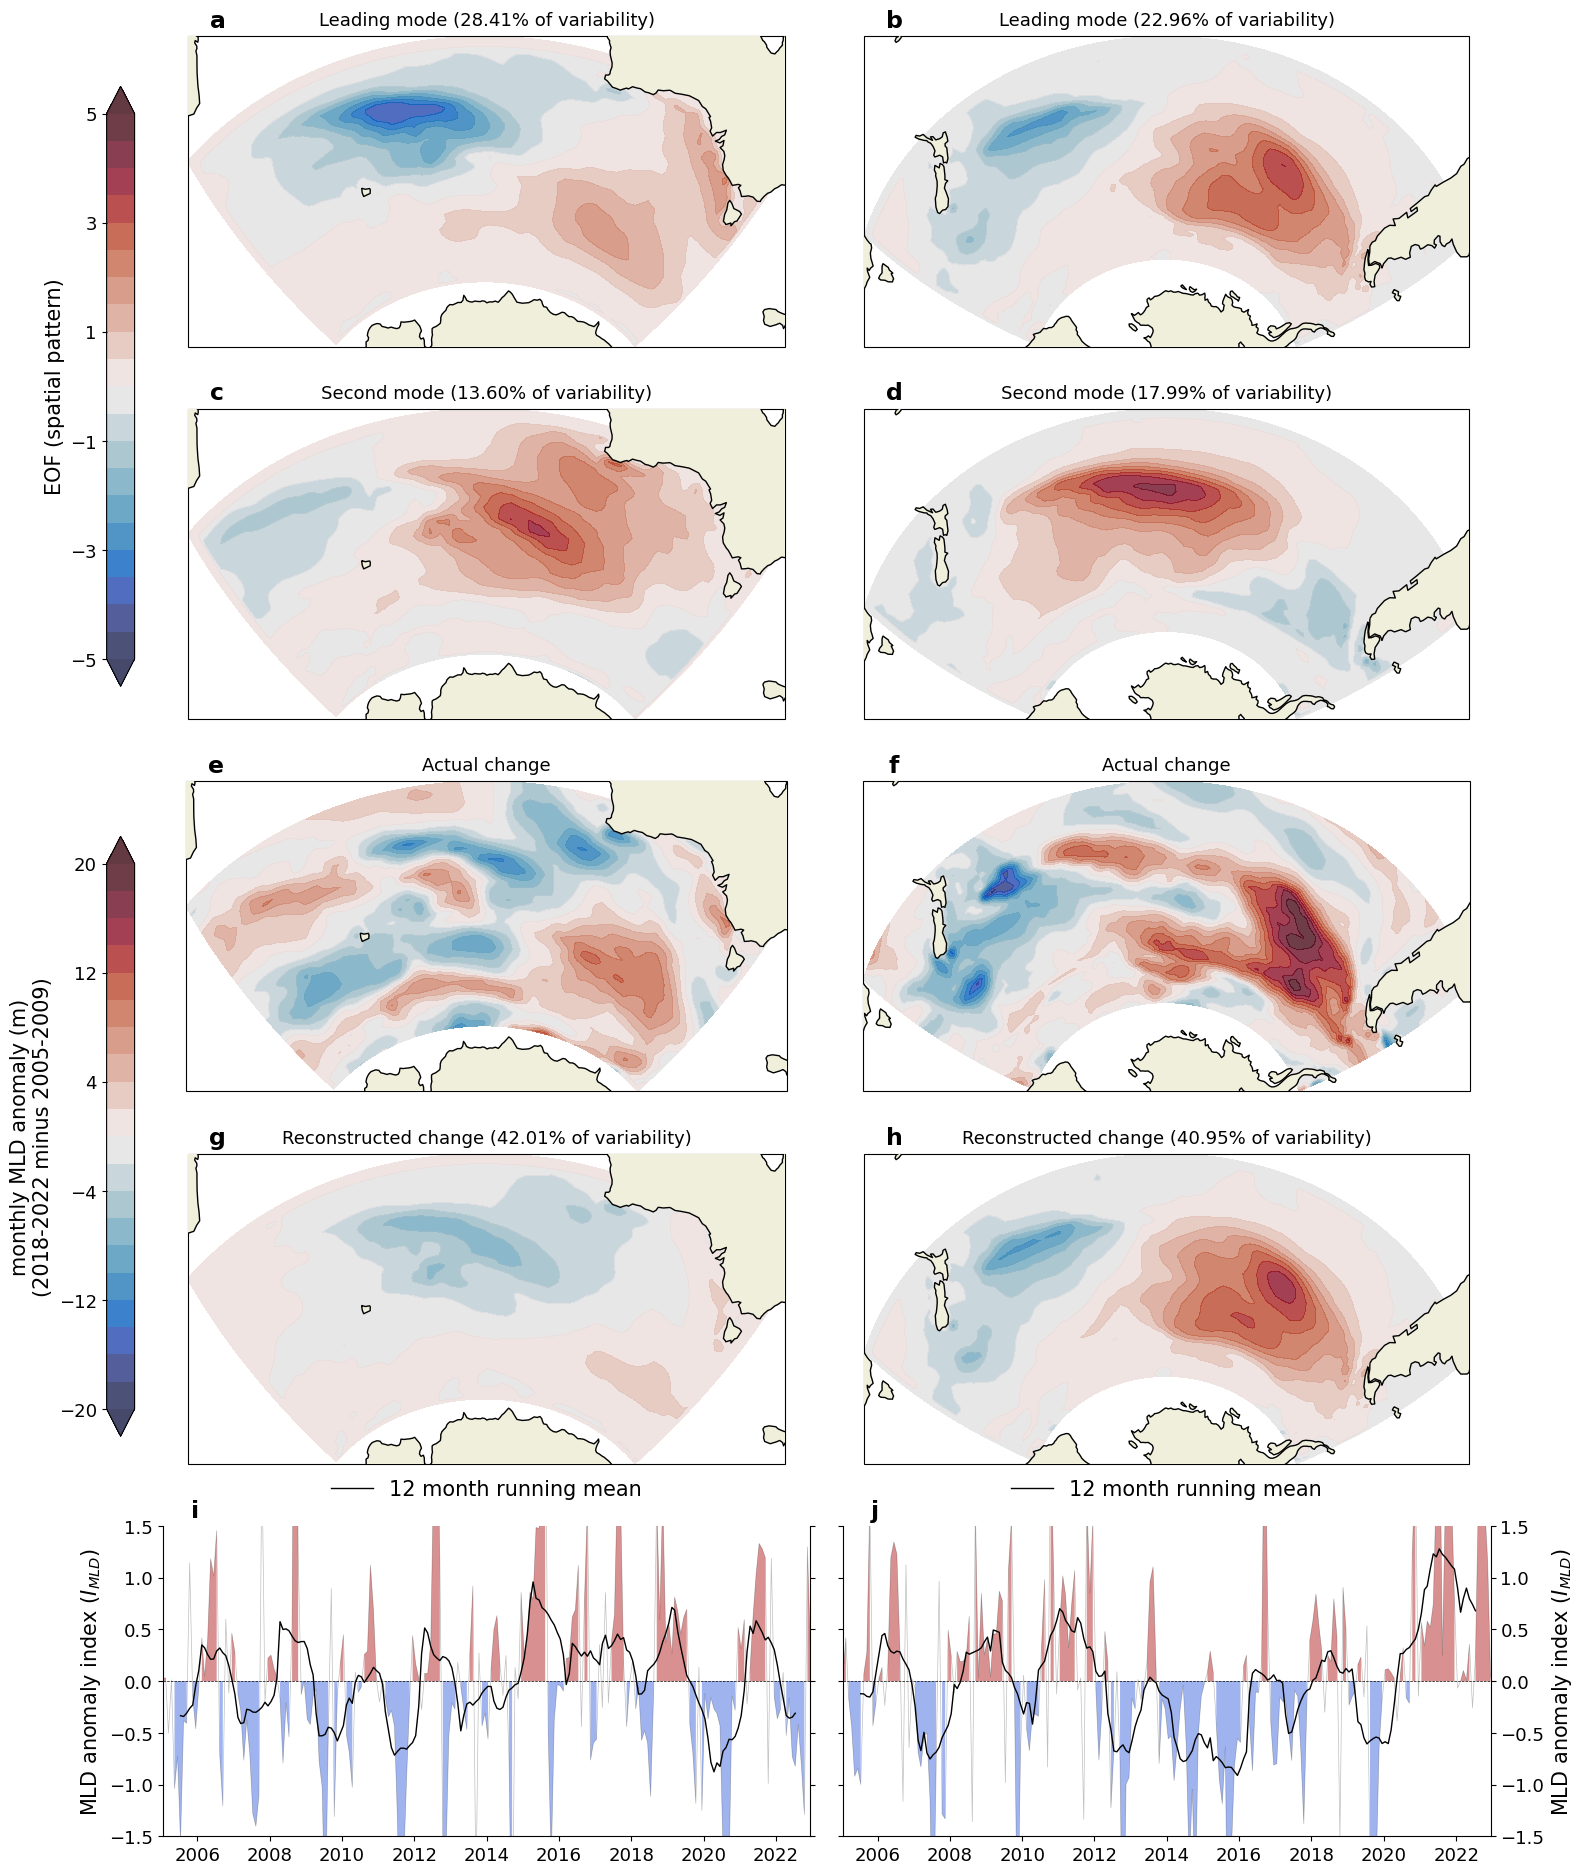

In [148]:
#%% Figure 1 (hindcast)

sind_proj = ccrs.Orthographic(central_latitude=-55, central_longitude=95)
spac_proj = ccrs.Orthographic(central_latitude=-60, central_longitude=225)

paclons = U_pac_reg.coords['lon']
paclats = U_pac_reg.coords['lat']
indlons = U_ind_reg.coords['lon']
indlats = U_ind_reg.coords['lat']

levs1 = np.arange(-5,5.1,0.5)
levs2 = np.arange(-20,21,2)
colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15
wid = 1.0

fig = plt.figure(figsize=(16,20), facecolor='w')
gs = GridSpec(5,2)

ax1 = plt.subplot(gs[0,0], projection=sind_proj)
ax2 = plt.subplot(gs[0,1], projection=spac_proj)
ax3 = plt.subplot(gs[1,0], projection=sind_proj)
ax4 = plt.subplot(gs[1,1], projection=spac_proj)
ax5 = plt.subplot(gs[2,0], projection=sind_proj)
ax6 = plt.subplot(gs[2,1], projection=spac_proj)
ax7 = plt.subplot(gs[3,0], projection=sind_proj)
ax8 = plt.subplot(gs[3,1], projection=spac_proj)
ax9 = plt.subplot(gs[4,0])
ax10 = plt.subplot(gs[4,1])

ax1.add_feature(cfeature.LAND, zorder=3)
ax1.add_feature(cfeature.COASTLINE, zorder=3)
ax2.add_feature(cfeature.LAND, zorder=3)
ax2.add_feature(cfeature.COASTLINE, zorder=3)
ax3.add_feature(cfeature.LAND, zorder=3)
ax3.add_feature(cfeature.COASTLINE, zorder=3)
ax4.add_feature(cfeature.LAND, zorder=3)
ax4.add_feature(cfeature.COASTLINE, zorder=3)
ax5.add_feature(cfeature.LAND, zorder=3)
ax5.add_feature(cfeature.COASTLINE, zorder=3)
ax6.add_feature(cfeature.LAND, zorder=3)
ax6.add_feature(cfeature.COASTLINE, zorder=3)
ax7.add_feature(cfeature.LAND, zorder=3)
ax7.add_feature(cfeature.COASTLINE, zorder=3)
ax8.add_feature(cfeature.LAND, zorder=3)
ax8.add_feature(cfeature.COASTLINE, zorder=3)


ax9.tick_params(labelsize=fstic, right=True)
ax10.tick_params(labelsize=fstic, labelleft=False, right=True, labelright=True)
ax9.spines['top'].set_visible(False)
ax10.spines['top'].set_visible(False)

p1 = ax1.contourf(indlons,indlats, U_ind_reg.sel(mode=0) * (-1) + 1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
p2 = ax2.contourf(paclons,paclats, U_pac_reg.sel(mode=0) * (-1) , transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
plt.text(0.5,1.05,'Leading mode (%.2f%% of variability)'%(VE_ind.sel(mode=0).values*100), transform=ax1.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Leading mode (%.2f%% of variability)'%(VE_pac.sel(mode=0).values*100), transform=ax2.transAxes, va='center', ha='center', fontsize=fstic)

imodes = 1 
p3 = ax3.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes) * (-1) + 1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
p4 = ax4.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes) * (-1), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
plt.text(0.5,1.05,'Second mode (%.2f%% of variability)'%(VE_ind.sel(mode=imodes).values*100), transform=ax3.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Second mode (%.2f%% of variability)'%(VE_pac.sel(mode=imodes).values*100), transform=ax4.transAxes, va='center', ha='center', fontsize=fstic)

paclons = spac_cflx_reg_anom.coords['x']
paclats = spac_cflx_reg_anom.coords['y']
indlons = sind_cflx_reg_anom.coords['x']
indlats = sind_cflx_reg_anom.coords['y']

p5 = ax5.contourf(indlons,indlats, sind_cflx_reg_anom.isel(time=slice(-60,-1)).mean(dim='time') - sind_cflx_reg_anom.isel(time=slice(0,60)).mean(dim="time"), \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')
p6 = ax6.contourf(paclons,paclats, spac_cflx_reg_anom.isel(time=slice(-60,-1)).mean(dim='time') - spac_cflx_reg_anom.isel(time=slice(0,60)).mean(dim="time"), \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')

paclons = U_pac_reg.coords['lon']
paclats = U_pac_reg.coords['lat']
indlons = U_ind_reg.coords['lon']
indlats = U_ind_reg.coords['lat']

p7 = ax7.contourf(indlons,indlats, X_ind_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(-60,-1)).mean(dim="time") - \
                  X_ind_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(0,60)).mean(dim="time") + 1e-2, \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')
p8 = ax8.contourf(paclons,paclats, X_pac_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(-60,-1)).mean(dim="time") - \
                  X_pac_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(0,60)).mean(dim="time"), \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')


ax9.plot(I_ind_pos.coords['time'], I_ind_pos, color='k', linewidth=0.5, linestyle='-', alpha=0.25)
ax9.plot(I_ind_pos.coords['time'], I_ind_pos*0, color='k', linewidth=0.5, linestyle='--', alpha=1.0)
ax9.plot(I_ind_pos.coords['time'], I_ind_pos.rolling(time=12, center=True).mean(), color='k', linewidth=1.0, linestyle='-', label="12 month running mean")
#ax9.plot(I_ind_pos.coords['time'], I_ind_pos.rolling(time=60, center=True).mean(), color='k', linewidth=2.0, linestyle='-', label="10 year running mean")
ax10.plot(I_pac_pos.coords['time'], I_pac_pos, color='k', linewidth=0.5, linestyle='-', alpha=0.25)
ax10.plot(I_pac_pos.coords['time'], I_pac_pos*0, color='k', linewidth=0.5, linestyle='--', alpha=1.0)
ax10.plot(I_pac_pos.coords['time'], I_pac_pos.rolling(time=12, center=True).mean(), color='k', linewidth=1.0, linestyle='-', label="12 month running mean")
#ax10.plot(I_pac_pos.coords['time'], I_pac_pos.rolling(time=60, center=True).mean(), color='k', linewidth=2.0, linestyle='-', label="10 year running mean")

ax9.legend(loc='upper center', frameon=False, fontsize=fslab, bbox_to_anchor=(0.5,1.21))
ax10.legend(loc='upper center', frameon=False, fontsize=fslab, bbox_to_anchor=(0.5,1.21))

ax9.fill_between(I_ind_pos.coords['time'], I_ind_pos.where(I_ind_pos > 0.0, other=np.nan), alpha=0.5, facecolor='firebrick')
ax9.fill_between(I_ind_pos.coords['time'], I_ind_pos.where(I_ind_pos < 0.0, other=np.nan), alpha=0.5, facecolor='royalblue')
ax10.fill_between(I_pac_pos.coords['time'], I_pac_pos.where(I_pac_pos > 0.0, other=np.nan), alpha=0.5, facecolor='firebrick')
ax10.fill_between(I_pac_pos.coords['time'], I_pac_pos.where(I_pac_pos < 0.0, other=np.nan), alpha=0.5, facecolor='royalblue')

#ax9.axvspan(I_ind_pos.coords['time'].sel(time="2006-01-01",method='nearest').values, \
#            I_ind_pos.coords['time'].sel(time="2006-12-31",method='nearest').values, color='goldenrod', alpha=0.25)
#ax9.axvspan(I_ind_pos.coords['time'].sel(time="2007-01-01",method='nearest').values, \
#            I_ind_pos.coords['time'].sel(time="2007-12-31",method='nearest').values, color='goldenrod', alpha=0.25)
#ax10.axvspan(I_pac_pos.coords['time'].sel(time="2006-01-01",method='nearest').values, \
#             I_pac_pos.coords['time'].sel(time="2006-12-31",method='nearest').values, color='goldenrod', alpha=0.25)
#ax10.axvspan(I_pac_pos.coords['time'].sel(time="2007-01-01",method='nearest').values, \
#             I_pac_pos.coords['time'].sel(time="2007-12-31",method='nearest').values, color='goldenrod', alpha=0.25)

ax9.set_xlim(I_pac_pos.coords['time'].min(), I_pac_pos.coords['time'].max())
ax10.set_xlim(I_pac_pos.coords['time'].min(), I_pac_pos.coords['time'].max())
ax9.set_ylabel("MLD anomaly index ($I_{MLD}$)", fontsize=fslab)
ax10.set_ylabel("MLD anomaly index ($I_{MLD}$)", fontsize=fslab)
ax10.yaxis.set_label_position('right')

ax9.set_ylim(-1.5,1.5)
ax10.set_ylim(-1.5,1.5)

cbax1 = fig.add_axes([0.085,0.625,0.0175,0.30])
cbax5 = fig.add_axes([0.085,0.25,0.0175,0.30])

cbar1 = plt.colorbar(p1, cax=cbax1, orientation='vertical', ticks=levs1[::4])
cbar1.ax.tick_params(labelsize=fstic, right=False, labelright=False, left=True, labelleft=True)
cbar1.ax.set_ylabel('EOF (spatial pattern)', fontsize=fslab)
cbar1.ax.yaxis.set_label_position('left')

cbar5 = plt.colorbar(p5, cax=cbax5, orientation='vertical', ticks=levs2[::4])
cbar5.ax.tick_params(labelsize=fstic, right=False, labelright=False, left=True, labelleft=True)
cbar5.ax.set_ylabel('monthly MLD anomaly (m)\n(2018-2022 minus 2005-2009)', fontsize=fslab)
cbar5.ax.yaxis.set_label_position('left')

plt.text(0.5,1.05,'Actual change', transform=ax5.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Actual change', transform=ax6.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Reconstructed change (%.2f%% of variability)'%(VE_ind.cumsum().sel(mode=imodes).values*100), transform=ax7.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Reconstructed change (%.2f%% of variability)'%(VE_pac.cumsum().sel(mode=imodes).values*100), transform=ax8.transAxes, va='center', ha='center', fontsize=fstic)

plt.subplots_adjust(left=0.12, top=0.95, right=0.95, bottom=0.05, wspace=0.05)

xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,'d', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,'e', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,'f', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)
plt.text(xx,yy,'g', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax7.transAxes)
plt.text(xx,yy,'h', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax8.transAxes)
plt.text(xx,yy,'i', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax9.transAxes)
plt.text(xx,yy,'j', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax10.transAxes)


In [150]:
fig.savefig("fig-hindcast_mld_trend_reconstructed_2005-2022.png", dpi=300)

I_ind_pos.name = "I_MLD"
I_pac_pos.name = "I_MLD"
I_ind_neg.name = "I_MLD"
I_pac_neg.name = "I_MLD"

#os.remove('/home/581/pjb581/analysis_samw/Ipos_ind_2005-2022.nc')
#os.remove('/home/581/pjb581/analysis_samw/Ipos_pac_2005-2022.nc')
#os.remove('/home/581/pjb581/analysis_samw/Ineg_ind_2005-2022.nc')
#os.remove('/home/581/pjb581/analysis_samw/Ineg_pac_2005-2022.nc')

I_ind_pos.to_netcdf('/home/581/pjb581/analysis_samw/Ipos_ind_2005-2022.nc')
I_pac_pos.to_netcdf('/home/581/pjb581/analysis_samw/Ipos_pac_2005-2022.nc')
I_ind_neg.to_netcdf('/home/581/pjb581/analysis_samw/Ineg_ind_2005-2022.nc')
I_pac_neg.to_netcdf('/home/581/pjb581/analysis_samw/Ineg_pac_2005-2022.nc')


## Compute the positive and negative composite events from MLD index created from the EN4 T & S --> MLD data

### reconstruct the MLD flux from EOFs

In [151]:
%%time

sind_ds_recon = U_ind_reg * S_ind * V_ind
spac_ds_recon = U_pac_reg * S_pac * V_pac


CPU times: user 1.21 s, sys: 2.2 s, total: 3.42 s
Wall time: 3.41 s


### Load the indices

In [158]:
%%time

datapath = "/home/581/pjb581/analysis_samw"

Ipos_pac_EN4 = xr.open_dataset(datapath + "/Ipos_pac_EN4_2005-2022.nc").squeeze()
Ipos_ind_EN4 = xr.open_dataset(datapath + "/Ipos_ind_EN4_2005-2022.nc").squeeze()

Ipos_pac_sim = xr.open_dataset(datapath + "/Ipos_pac_2005-2022.nc").squeeze()
Ipos_ind_sim = xr.open_dataset(datapath + "/Ipos_ind_2005-2022.nc").squeeze()

Ipos_pac_EN4 = Ipos_pac_EN4["I_MLD"]
Ipos_ind_EN4 = Ipos_ind_EN4["I_MLD"]
Ipos_pac_sim = Ipos_pac_sim["I_MLD"]
Ipos_ind_sim = Ipos_ind_sim["I_MLD"]


CPU times: user 31.6 ms, sys: 3.61 ms, total: 35.2 ms
Wall time: 41.4 ms


### Find the composite patterns using the MLD I+ index

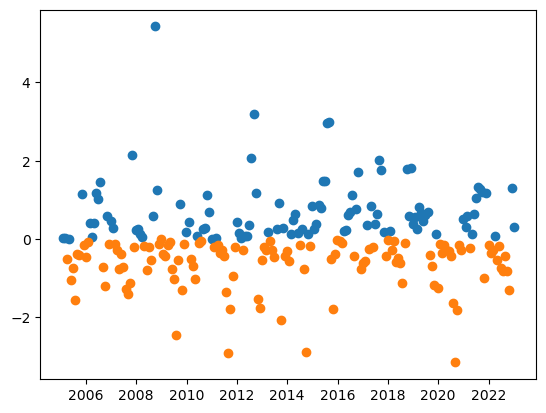

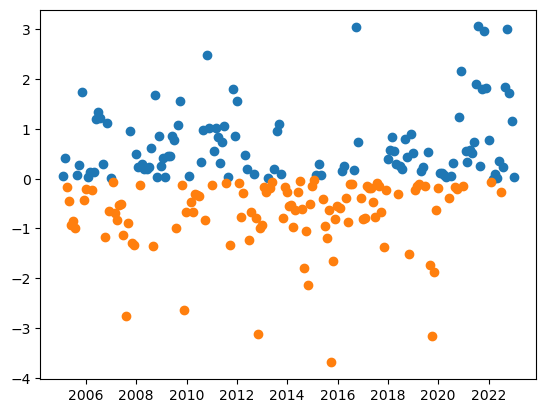

In [159]:
ind_pos = Ipos_ind_sim > 0.0
pac_pos = Ipos_pac_sim > 0.0
ind_neg = Ipos_ind_sim < 0.0
pac_neg = Ipos_pac_sim < 0.0

ind_pos_w = Ipos_ind_sim[ind_pos]
pac_pos_w = Ipos_pac_sim[pac_pos]
ind_neg_w = Ipos_ind_sim[ind_neg]
pac_neg_w = Ipos_pac_sim[pac_neg]

# resample the time axis to align with the EOF chl-a data
ind_pos_w = ind_pos_w.resample(time="ME").mean()
ind_neg_w = ind_neg_w.resample(time="ME").mean()
pac_pos_w = pac_pos_w.resample(time="ME").mean()
pac_neg_w = pac_neg_w.resample(time="ME").mean()

plt.figure()
plt.scatter(ind_pos_w.coords['time'], ind_pos_w)
plt.scatter(ind_neg_w.coords['time'], ind_neg_w)
plt.figure()
plt.scatter(pac_pos_w.coords['time'], pac_pos_w)
plt.scatter(pac_neg_w.coords['time'], pac_neg_w)

### Reconstruct the CO2 flux using the leading modes

In [160]:
%%time

### full 
ind_recon_pos = (sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').resample(time="ME").mean() * ind_pos_w).sum(dim='time', skipna=True) / ind_pos_w.sum(dim='time', skipna=True)
ind_recon_neg = (sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').resample(time="ME").mean() * ind_neg_w).sum(dim='time', skipna=True) / ind_neg_w.sum(dim='time', skipna=True)
pac_recon_pos = (spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').resample(time="ME").mean() * pac_pos_w).sum(dim='time', skipna=True) / pac_pos_w.sum(dim='time', skipna=True)
pac_recon_neg = (spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').resample(time="ME").mean() * pac_neg_w).sum(dim='time', skipna=True) / pac_neg_w.sum(dim='time', skipna=True)

### only summer
ind_recon_pos_summer = (sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([12, 1, 2]), drop=True).resample(time="ME").mean() * ind_pos_w).sum(dim='time', skipna=True) / ind_pos_w.sum(dim='time', skipna=True)
ind_recon_neg_summer = (sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([12, 1, 2]), drop=True).resample(time="ME").mean() * ind_neg_w).sum(dim='time', skipna=True) / ind_neg_w.sum(dim='time', skipna=True)
pac_recon_pos_summer = (spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([12, 1, 2]), drop=True).resample(time="ME").mean() * pac_pos_w).sum(dim='time', skipna=True) / pac_pos_w.sum(dim='time', skipna=True)
pac_recon_neg_summer = (spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([12, 1, 2]), drop=True).resample(time="ME").mean() * pac_neg_w).sum(dim='time', skipna=True) / pac_neg_w.sum(dim='time', skipna=True)

### only winter
ind_recon_pos_winter = (sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([6, 7, 8, 9]), drop=True).resample(time="ME").mean() * ind_pos_w).sum(dim='time', skipna=True) / ind_pos_w.sum(dim='time', skipna=True)
ind_recon_neg_winter = (sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([6, 7, 8, 9]), drop=True).resample(time="ME").mean() * ind_neg_w).sum(dim='time', skipna=True) / ind_neg_w.sum(dim='time', skipna=True)
pac_recon_pos_winter = (spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([6, 7, 8, 9]), drop=True).resample(time="ME").mean() * pac_pos_w).sum(dim='time', skipna=True) / pac_pos_w.sum(dim='time', skipna=True)
pac_recon_neg_winter = (spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([6, 7, 8, 9]), drop=True).resample(time="ME").mean() * pac_neg_w).sum(dim='time', skipna=True) / pac_neg_w.sum(dim='time', skipna=True)


CPU times: user 3.53 s, sys: 993 ms, total: 4.52 s
Wall time: 4.55 s


### normalise it to the standard deviation of CO2 flux anomaly

In [161]:
%%time

sind_std = sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').std(dim='time')
spac_std = spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').std(dim='time')

ind_recon_pos_per = ind_recon_pos / sind_std * 100
ind_recon_neg_per = ind_recon_neg / sind_std * 100
pac_recon_pos_per = pac_recon_pos / spac_std * 100
pac_recon_neg_per = pac_recon_neg / spac_std * 100

sind_std = sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([12, 1, 2]), drop=True).std(dim='time')
spac_std = spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([12, 1, 2]), drop=True).std(dim='time')

ind_recon_pos_summer_per = ind_recon_pos_summer / sind_std * 100
ind_recon_neg_summer_per = ind_recon_neg_summer / sind_std * 100
pac_recon_pos_summer_per = pac_recon_pos_summer / spac_std * 100
pac_recon_neg_summer_per = pac_recon_neg_summer / spac_std * 100

sind_std = sind_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([6, 7, 8, 9]), drop=True).std(dim='time')
spac_std = spac_ds_recon.sel(mode=slice(0,4)).sum(dim='mode').where(sind_ds_recon.time.dt.month.isin([6, 7, 8, 9]), drop=True).std(dim='time')

ind_recon_pos_winter_per = ind_recon_pos_winter / sind_std * 100
ind_recon_neg_winter_per = ind_recon_neg_winter / sind_std * 100
pac_recon_pos_winter_per = pac_recon_pos_winter / spac_std * 100
pac_recon_neg_winter_per = pac_recon_neg_winter / spac_std * 100


CPU times: user 403 ms, sys: 224 ms, total: 627 ms
Wall time: 623 ms


Text(0.5, 1.1, 'MLD anomaly composite (I$_{MLD}$ > 0)')

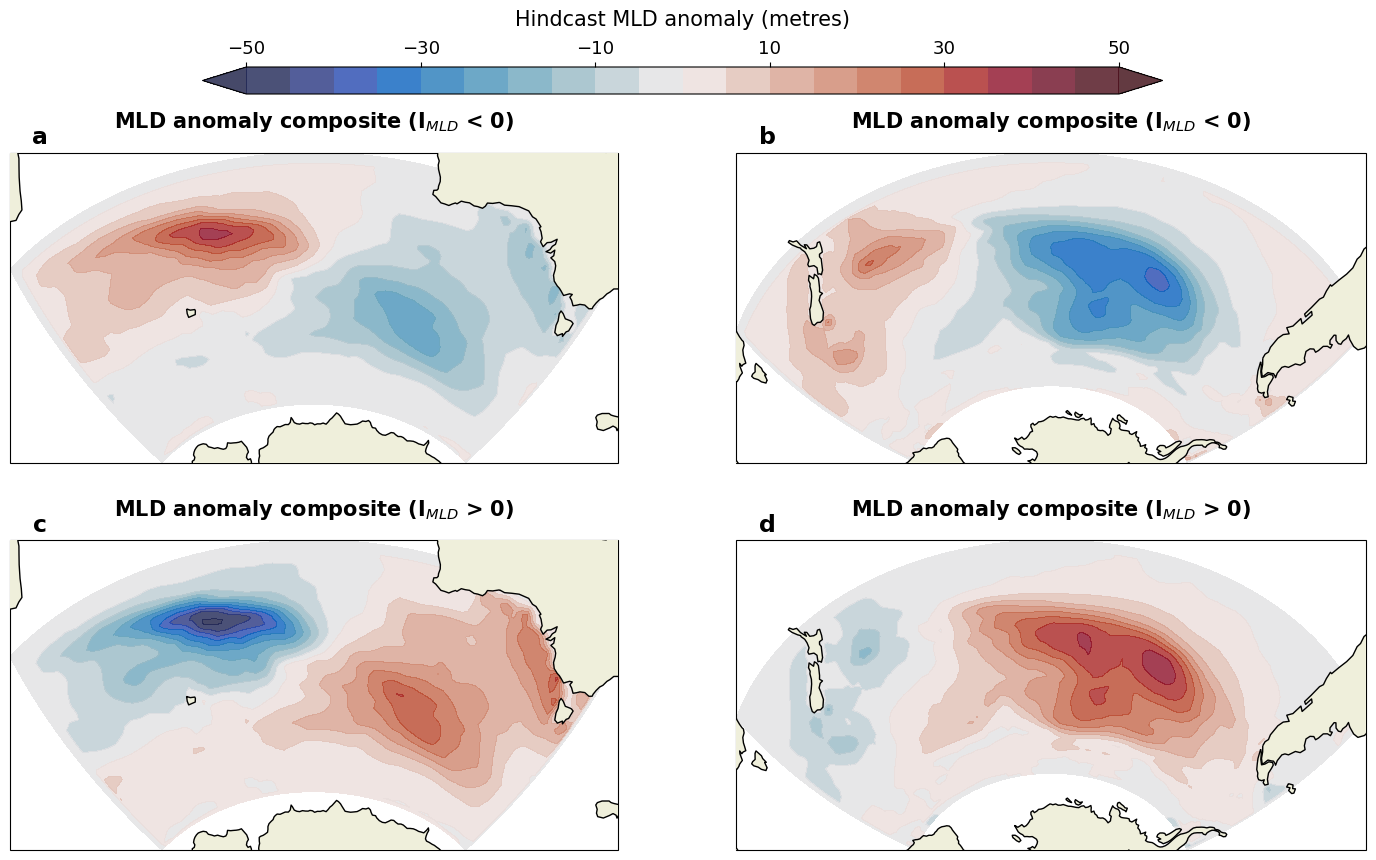

In [162]:
sind_proj = ccrs.Orthographic(central_latitude=ilat1+(ilat2-ilat1)*0.5, central_longitude=ilon1+(ilon2-ilon1)*0.5)
spac_proj = ccrs.Orthographic(central_latitude=ilat1+(ilat2-ilat1)*0.5, central_longitude=plon1+(plon2-plon1)*0.5)

paclons = U_pac_reg.coords['lon']
paclats = U_pac_reg.coords['lat']
indlons = U_ind_reg.coords['lon']
indlats = U_ind_reg.coords['lat']


levs = np.arange(-50,51,5)
colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15
wid = 1.0

fig = plt.figure(figsize=(16,9), facecolor='w')
gs = GridSpec(2,2)

ax1 = plt.subplot(gs[0,0], projection=sind_proj)
ax2 = plt.subplot(gs[0,1], projection=spac_proj)
ax3 = plt.subplot(gs[1,0], projection=sind_proj)
ax4 = plt.subplot(gs[1,1], projection=spac_proj)

ax1.add_feature(cfeature.LAND, zorder=3)
ax1.add_feature(cfeature.COASTLINE, zorder=3)
ax2.add_feature(cfeature.LAND, zorder=3)
ax2.add_feature(cfeature.COASTLINE, zorder=3)
ax3.add_feature(cfeature.LAND, zorder=3)
ax3.add_feature(cfeature.COASTLINE, zorder=3)
ax4.add_feature(cfeature.LAND, zorder=3)
ax4.add_feature(cfeature.COASTLINE, zorder=3)

p1 = ax1.contourf(indlons,indlats, ind_recon_neg, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p2 = ax2.contourf(paclons,paclats, pac_recon_neg, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')

p3 = ax3.contourf(indlons,indlats, ind_recon_pos, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p4 = ax4.contourf(paclons,paclats, pac_recon_pos, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')

cbax = fig.add_axes([0.2,0.89,0.6,0.03])
cbar1 = plt.colorbar(p1, cax=cbax, orientation='horizontal', ticks=levs[::4])
cbar1.ax.tick_params(labelsize=fstic, labelbottom=False, bottom=False, labeltop=True, top=True)
cbar1.ax.set_xlabel('Hindcast MLD anomaly (metres)', fontsize=fslab, labelpad=10)
cbar1.ax.xaxis.set_label_position('top')

plt.subplots_adjust(left=0.05, top=0.825, right=0.95, bottom=0.05, wspace=0.05, hspace=0.25)

xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,'d', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)

xx = 0.5; yy = 1.10
plt.text(xx,yy,'MLD anomaly composite (I$_{MLD}$ < 0)', fontweight='bold', fontsize=fslab, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'MLD anomaly composite (I$_{MLD}$ < 0)', fontweight='bold', fontsize=fslab, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,'MLD anomaly composite (I$_{MLD}$ > 0)', fontweight='bold', fontsize=fslab, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,'MLD anomaly composite (I$_{MLD}$ > 0)', fontweight='bold', fontsize=fslab, va='center', ha='center', transform=ax4.transAxes)


In [163]:
fig.savefig("/home/581/pjb581/analysis_samw/fig-MLD_composite_reconstructions_with_hindcast_Ipos_Ineg_2005-2022.png", dpi=300)
